# Droneport Destekli İHA Görevleri İçin Karar Destek ve Enerji Optimizasyon Sistemi

## Projenin Amacı

Bu çalışmada, Droneport destekli insansız hava aracı görevlerinde ihtiyaç duyulan enerjinin makine öğrenmesi yöntemleriyle tahmin edilmesi amaçlanmıştır. Görev mesafesi, uçuş hızı, operasyon süresi, faydalı yük ağırlığı, rüzgâr hızı ve sıcaklık gibi değişkenlerin enerji ihtiyacı üzerindeki etkileri incelenecektir.

Tahmin edilen enerji ihtiyacı; bataryanın başlangıç doluluk oranı ve sağlık durumu ile birlikte değerlendirilerek görevin uygunluk durumu belirlenecektir. Riskli veya uygun olmayan görevler için başlangıç batarya seviyesinin artırılması, faydalı yükün azaltılması veya daha uygun çevresel koşulların beklenmesi gibi öneriler oluşturulacaktır.

## Çalışmanın Kapsamı

Bu proje bir kavram kanıtlama çalışmasıdır. Gerçek cihaz verisi kullanılmamıştır. Sistem davranışını temsil eden mantıksal ve matematiksel ilişkiler kullanılarak sentetik bir veri kümesi oluşturulacaktır. Geliştirilecek modelin gerçek bir sistemde kullanılabilmesi için cihazdan elde edilen gerçek verilerle yeniden eğitilmesi ve doğrulanması gerekmektedir.



In [1]:
# Temel Python kütüphaneleri içe aktarılıyor.
import sys
import random
import warnings

# Veri işleme ve sayısal hesaplama kütüphaneleri içe aktarılıyor.
import numpy as np
import pandas as pd

# Veri görselleştirme kütüphaneleri içe aktarılıyor.
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Makine öğrenmesi kütüphanesinin sürüm kontrolü için içe aktarılıyor.
import sklearn

# Gereksiz uyarıların Notebook çıktısında gösterilmesi engelleniyor.
warnings.filterwarnings("ignore")

# Sonuçların tekrar üretilebilir olması için sabit rastgelelik değeri belirleniyor.
RASTGELELIK_DEGERI = 42
random.seed(RASTGELELIK_DEGERI)
np.random.seed(RASTGELELIK_DEGERI)

# Grafiklerin genel görünüm ayarları yapılıyor.
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.titlesize"] = 13

# Kullanılan çalışma ortamı ve kütüphane sürümleri ekrana yazdırılıyor.
print("Çalışma ortamı başarıyla hazırlandı.")
print("-" * 45)
print(f"Python sürümü       : {sys.version.split()[0]}")
print(f"NumPy sürümü        : {np.__version__}")
print(f"Pandas sürümü       : {pd.__version__}")
print(f"Matplotlib sürümü   : {matplotlib.__version__}")
print(f"Seaborn sürümü      : {sns.__version__}")
print(f"Scikit-learn sürümü : {sklearn.__version__}")
print(f"Rastgelelik değeri  : {RASTGELELIK_DEGERI}")


Çalışma ortamı başarıyla hazırlandı.
---------------------------------------------
Python sürümü       : 3.13.16
NumPy sürümü        : 2.1.3
Pandas sürümü       : 2.2.3
Matplotlib sürümü   : 3.10.0
Seaborn sürümü      : 0.13.2
Scikit-learn sürümü : 1.6.1
Rastgelelik değeri  : 42


## 1. Sentetik Veri Kümesinin Tasarlanması

Her satırın bir İHA görev senaryosunu temsil ettiği 5.000 kayıtlık sentetik bir veri kümesi oluşturulacaktır. Veri üretimi sırasında tamamen bağımsız ve tekdüze değerler kullanılmayacak; değişkenler arasındaki mantıksal ilişkiler korunacaktır.

Görev süresi; toplam görev mesafesi, ortalama uçuş hızı ve operasyon süresi kullanılarak hesaplanacaktır. Batarya sağlığı ise şarj döngüsü sayısıyla ilişkili olacak şekilde üretilecektir. Rüzgâr hızı, sıcaklık, faydalı yük ve diğer görev koşullarının enerji ihtiyacı üzerindeki doğrusal ve doğrusal olmayan etkileri daha sonraki aşamalarda tanımlanacaktır.

Bu çalışmada kullanılan değer aralıkları, gerçek bir ticari ürünün teknik özelliklerini temsil etmemektedir. Belirlenen sınırlar yalnızca geliştirilen kavram kanıtlama çalışmasının simülasyon varsayımlarıdır.



In [2]:
# Sentetik veri üretiminde kullanılacak genel simülasyon ayarları tanımlanıyor.
KAYIT_SAYISI = 5000
NOMINAL_BATARYA_KAPASITESI_WH = 600.0
GUVENLI_BATARYA_REZERVI_YUZDE = 20.0

# Değişkenler için kabul edilen simülasyon sınırları tanımlanıyor.
simulasyon_sinirlari = {
    "Toplam görev mesafesi (km)": (1.0, 20.0),
    "Ortalama uçuş hızı (km/sa)": (20.0, 50.0),
    "Operasyon süresi (dk)": (0.0, 12.0),
    "Faydalı yük ağırlığı (kg)": (0.0, 2.0),
    "Ortalama rüzgâr hızı (m/sn)": (0.0, 14.0),
    "Ortam sıcaklığı (°C)": (-10.0, 40.0),
    "Başlangıç batarya seviyesi (%)": (50.0, 100.0),
    "Şarj döngüsü sayısı": (0, 500),
    "Batarya sağlığı (%)": (70.0, 100.0),
    "Batarya sıcaklığı (°C)": (-5.0, 45.0)
}

# Simülasyon sınırlarının daha okunabilir gösterilmesi için tablo oluşturuluyor.
sinirlar_tablosu = pd.DataFrame(
    [
        {
            "Değişken": degisken,
            "En Düşük Değer": sinirlar[0],
            "En Yüksek Değer": sinirlar[1]
        }
        for degisken, sinirlar in simulasyon_sinirlari.items()
    ]
)

# Temel proje ayarları ekrana yazdırılıyor.
print("Simülasyon ayarları başarıyla tanımlandı.")
print("-" * 50)
print(f"Oluşturulacak görev kaydı : {KAYIT_SAYISI}")
print(
    f"Nominal batarya kapasitesi: "
    f"{NOMINAL_BATARYA_KAPASITESI_WH:.0f} Wh"
)
print(
    f"Güvenli batarya rezervi   : "
    f"%{GUVENLI_BATARYA_REZERVI_YUZDE:.0f}"
)
print("\nDeğişkenler için belirlenen simülasyon sınırları:")

display(sinirlar_tablosu)


Simülasyon ayarları başarıyla tanımlandı.
--------------------------------------------------
Oluşturulacak görev kaydı : 5000
Nominal batarya kapasitesi: 600 Wh
Güvenli batarya rezervi   : %20

Değişkenler için belirlenen simülasyon sınırları:


,Değişken,En Düşük Değer,En Yüksek Değer
0,Toplam görev mesafesi (km),1.0,20.0
1,Ortalama uçuş hızı (km/sa),20.0,50.0
2,Operasyon süresi (dk),0.0,12.0
3,Faydalı yük ağırlığı (kg),0.0,2.0
4,Ortalama rüzgâr hızı (m/sn),0.0,14.0
5,Ortam sıcaklığı (°C),-10.0,40.0
6,Başlangıç batarya seviyesi (%),50.0,100.0
7,Şarj döngüsü sayısı,0.0,500.0
8,Batarya sağlığı (%),70.0,100.0
9,Batarya sıcaklığı (°C),-5.0,45.0


### 1.1. Görev, Çevre ve Batarya Değişkenlerinin Üretilmesi

Sentetik görev değişkenlerinin daha gerçekçi bir dağılım göstermesi amacıyla farklı olasılık dağılımlarından yararlanılmıştır. Olağan çalışma koşullarının veri kümesinde daha sık, sınır değerlere yakın koşulların ise daha seyrek görülmesi sağlanmıştır.

Görev süresi bağımsız olarak üretilmemiştir. Toplam görev mesafesi, ortalama uçuş hızı ve operasyon süresi kullanılarak hesaplanmıştır. Benzer şekilde batarya sağlığı da şarj döngüsü sayısıyla ilişkili olacak şekilde oluşturulmuştur. Böylece değişkenler arasındaki temel mantıksal ilişkiler korunmuştur.


In [3]:
# Görevleri benzersiz olarak tanımlamak için görev numaraları oluşturuluyor.
gorev_no = np.arange(1, KAYIT_SAYISI + 1)

# Görev mesafesi üretiliyor.
# Beta dağılımı sayesinde kısa ve orta mesafeli görevlerin daha sık oluşması sağlanıyor.
gorev_mesafesi_km = 1.0 + (
    np.random.beta(a=2.0, b=3.0, size=KAYIT_SAYISI) * 19.0
)

# Ortalama uçuş hızı normal dağılımdan üretiliyor ve belirlenen sınırlar içinde tutuluyor.
ortalama_ucus_hizi_kmh = np.clip(
    np.random.normal(loc=34.0, scale=6.0, size=KAYIT_SAYISI),
    20.0,
    50.0
)

# Operasyon süresi üretiliyor.
# Kısa operasyonların uzun operasyonlardan daha sık gerçekleşmesi amaçlanıyor.
operasyon_suresi_dk = (
    np.random.beta(a=1.5, b=3.0, size=KAYIT_SAYISI) * 12.0
)

# Faydalı yük ağırlığı üretiliyor.
# Hafif ve orta ağırlıktaki yüklerin daha sık görülmesi sağlanıyor.
faydali_yuk_kg = (
    np.random.beta(a=1.7, b=3.5, size=KAYIT_SAYISI) * 2.0
)

# Rüzgâr hızı Gamma dağılımından üretiliyor.
# Düşük ve orta rüzgâr hızları daha sık, yüksek rüzgâr hızları daha seyrek oluşturuluyor.
ruzgar_hizi_mps = np.clip(
    np.random.gamma(shape=2.0, scale=2.0, size=KAYIT_SAYISI),
    0.0,
    14.0
)

# Ortam sıcaklığı normal dağılımdan üretilerek simülasyon sınırlarında tutuluyor.
ortam_sicakligi_c = np.clip(
    np.random.normal(loc=18.0, scale=10.0, size=KAYIT_SAYISI),
    -10.0,
    40.0
)

# Başlangıç batarya seviyesi üretiliyor.
# Görevlerin çoğunun yüksek batarya seviyesiyle başladığı varsayılıyor.
baslangic_batarya_yuzde = 50.0 + (
    np.random.beta(a=5.0, b=2.0, size=KAYIT_SAYISI) * 50.0
)

# Şarj döngüsü sayısı üretiliyor.
# Düşük ve orta döngü sayısına sahip bataryaların daha sık olması sağlanıyor.
sarj_dongusu_sayisi = np.rint(
    np.random.beta(a=1.5, b=3.0, size=KAYIT_SAYISI) * 500
).astype(int)

# Batarya sağlığı, şarj döngüsü sayısıyla ters ilişkili olacak şekilde hesaplanıyor.
# Aynı döngü sayısındaki bataryaların tamamen aynı olmaması için kontrollü gürültü ekleniyor.
batarya_sagligi_yuzde = (
    100.0
    - (0.05 * sarj_dongusu_sayisi)
    + np.random.normal(loc=0.0, scale=1.8, size=KAYIT_SAYISI)
)
batarya_sagligi_yuzde = np.clip(
    batarya_sagligi_yuzde,
    70.0,
    100.0
)

# Batarya sıcaklığı, ortam sıcaklığıyla ilişkili olacak şekilde üretiliyor.
# Şarj ve önceki kullanım gibi etkileri temsil etmek amacıyla fark ve gürültü ekleniyor.
batarya_sicakligi_c = (
    ortam_sicakligi_c
    + np.random.normal(loc=3.0, scale=4.0, size=KAYIT_SAYISI)
)
batarya_sicakligi_c = np.clip(
    batarya_sicakligi_c,
    -5.0,
    45.0
)

# Toplam görev süresi; uçuş süresi ve operasyon süresinin toplamı olarak hesaplanıyor.
ucus_suresi_dk = (
    gorev_mesafesi_km / ortalama_ucus_hizi_kmh
) * 60.0

toplam_gorev_suresi_dk = ucus_suresi_dk + operasyon_suresi_dk

# Üretilen değişkenler bir veri çerçevesinde birleştiriliyor.
gorev_verileri = pd.DataFrame({
    "gorev_no": gorev_no,
    "gorev_mesafesi_km": np.round(gorev_mesafesi_km, 2),
    "ortalama_ucus_hizi_kmh": np.round(ortalama_ucus_hizi_kmh, 2),
    "operasyon_suresi_dk": np.round(operasyon_suresi_dk, 2),
    "toplam_gorev_suresi_dk": np.round(toplam_gorev_suresi_dk, 2),
    "faydali_yuk_kg": np.round(faydali_yuk_kg, 2),
    "ruzgar_hizi_mps": np.round(ruzgar_hizi_mps, 2),
    "ortam_sicakligi_c": np.round(ortam_sicakligi_c, 2),
    "baslangic_batarya_yuzde": np.round(baslangic_batarya_yuzde, 2),
    "sarj_dongusu_sayisi": sarj_dongusu_sayisi,
    "batarya_sagligi_yuzde": np.round(batarya_sagligi_yuzde, 2),
    "batarya_sicakligi_c": np.round(batarya_sicakligi_c, 2)
})

# Veri kümesinin boyutu ve ilk beş görevi ekrana yazdırılıyor.
print("Temel görev değişkenleri başarıyla üretildi.")
print("-" * 50)
print(f"Satır sayısı : {gorev_verileri.shape[0]}")
print(f"Sütun sayısı: {gorev_verileri.shape[1]}")
print("\nVeri kümesindeki ilk beş görev:")

display(gorev_verileri.head())


Temel görev değişkenleri başarıyla üretildi.
--------------------------------------------------
Satır sayısı : 5000
Sütun sayısı: 12

Veri kümesindeki ilk beş görev:


,gorev_no,gorev_mesafesi_km,ortalama_ucus_hizi_kmh,operasyon_suresi_dk,toplam_gorev_suresi_dk,faydali_yuk_kg,ruzgar_hizi_mps,ortam_sicakligi_c,baslangic_batarya_yuzde,sarj_dongusu_sayisi,batarya_sagligi_yuzde,batarya_sicakligi_c
0,1,10.39,44.34,1.42,15.48,0.57,2.14,8.62,82.47,213,89.96,19.79
1,2,8.13,20.00,8.57,32.96,0.84,8.93,9.60,84.43,187,88.81,15.02
2,3,11.07,38.14,7.90,25.31,0.64,0.63,4.82,79.96,135,95.03,9.29
3,4,5.49,33.04,7.90,17.87,0.15,2.34,3.29,88.27,71,97.15,4.10
4,5,15.59,28.90,3.01,35.39,0.75,4.55,10.21,87.43,86,95.66,16.61


### 1.2. Üretilen Değişkenlerin İlk Kontrolü

Sentetik veri üretiminin ardından veri kümesinin boyutu, veri türleri, eksik değerleri ve değişkenlerin gözlenen değer aralıkları kontrol edilmiştir. Ayrıca görev süresinin belirlenen matematiksel ilişkiye uygun hesaplanıp hesaplanmadığı incelenmiştir.

Bu aşamanın amacı, enerji ihtiyacını temsil eden hedef değişken oluşturulmadan önce temel görev verilerinde yapısal veya mantıksal bir hata bulunmadığından emin olmaktır.



In [5]:
# Veri kümesinin temel yapısal özellikleri kontrol ediliyor.
print("VERİ KÜMESİ YAPISAL KONTROLÜ")
print("=" * 55)
print(f"Satır sayısı              : {gorev_verileri.shape[0]}")
print(f"Sütun sayısı              : {gorev_verileri.shape[1]}")
print(f"Tekrarlanan satır sayısı  : {gorev_verileri.duplicated().sum()}")
print(f"Tekrarlanan görev numarası: {gorev_verileri['gorev_no'].duplicated().sum()}")
print(f"Toplam eksik değer sayısı : {gorev_verileri.isna().sum().sum()}")

# Sayısal sütunların gözlenen en düşük, en yüksek ve ortalama değerleri hesaplanıyor.
kontrol_edilecek_sutunlar = [
    "gorev_mesafesi_km",
    "ortalama_ucus_hizi_kmh",
    "operasyon_suresi_dk",
    "toplam_gorev_suresi_dk",
    "faydali_yuk_kg",
    "ruzgar_hizi_mps",
    "ortam_sicakligi_c",
    "baslangic_batarya_yuzde",
    "sarj_dongusu_sayisi",
    "batarya_sagligi_yuzde",
    "batarya_sicakligi_c"
]

aralik_kontrol_tablosu = pd.DataFrame({
    "Değişken": kontrol_edilecek_sutunlar,
    "Gözlenen En Düşük": [
        gorev_verileri[sutun].min()
        for sutun in kontrol_edilecek_sutunlar
    ],
    "Gözlenen En Yüksek": [
        gorev_verileri[sutun].max()
        for sutun in kontrol_edilecek_sutunlar
    ],
    "Ortalama": [
        gorev_verileri[sutun].mean()
        for sutun in kontrol_edilecek_sutunlar
    ]
})

# Tablo değerlerinin okunabilir olması için ondalık basamak sayısı sınırlandırılıyor.
aralik_kontrol_tablosu[
    ["Gözlenen En Düşük", "Gözlenen En Yüksek", "Ortalama"]
] = aralik_kontrol_tablosu[
    ["Gözlenen En Düşük", "Gözlenen En Yüksek", "Ortalama"]
].round(2)

print("\nDEĞİŞKENLERİN GÖZLENEN DEĞER ARALIKLARI")
print("=" * 55)
display(aralik_kontrol_tablosu)

# Görev süresi yeniden hesaplanarak veri kümesindeki değerlerle karşılaştırılıyor.
hesaplanan_gorev_suresi = (
    (
        gorev_verileri["gorev_mesafesi_km"]
        / gorev_verileri["ortalama_ucus_hizi_kmh"]
    ) * 60.0
    + gorev_verileri["operasyon_suresi_dk"]
)

# İki ondalık basamağa yuvarlamadan kaynaklanabilecek küçük farklar hesaplanıyor.
sure_hatasi_dk = np.abs(
    gorev_verileri["toplam_gorev_suresi_dk"]
    - hesaplanan_gorev_suresi
)

# Yuvarlama etkisi dikkate alınarak kabul edilebilir fark 0,03 dakika olarak belirleniyor.
KABUL_EDILEBILIR_SURE_FARKI_DK = 0.03

print("\nMANTIKSAL İLİŞKİ KONTROLÜ")
print("=" * 55)
print(
    "Görev süresindeki en büyük hesaplama farkı: "
    f"{sure_hatasi_dk.max():.4f} dakika"
)
print(
    f"{KABUL_EDILEBILIR_SURE_FARKI_DK:.2f} dakikadan büyük "
    "fark bulunan kayıt sayısı: "
    f"{(sure_hatasi_dk > KABUL_EDILEBILIR_SURE_FARKI_DK).sum()}"
)

# Batarya sağlığı ile şarj döngüsü arasındaki ilişkinin yönü kontrol ediliyor.
dongu_saglik_korelasyonu = gorev_verileri[
    ["sarj_dongusu_sayisi", "batarya_sagligi_yuzde"]
].corr().iloc[0, 1]

print(
    "Şarj döngüsü ile batarya sağlığı korelasyonu: "
    f"{dongu_saglik_korelasyonu:.4f}"
)


VERİ KÜMESİ YAPISAL KONTROLÜ
Satır sayısı              : 5000
Sütun sayısı              : 12
Tekrarlanan satır sayısı  : 0
Tekrarlanan görev numarası: 0
Toplam eksik değer sayısı : 0

DEĞİŞKENLERİN GÖZLENEN DEĞER ARALIKLARI


,Değişken,Gözlenen En Düşük,Gözlenen En Yüksek,Ortalama
0,gorev_mesafesi_km,1.13,19.34,8.57
1,ortalama_ucus_hizi_kmh,20.00,50.00,33.98
2,operasyon_suresi_dk,0.01,11.26,3.98
3,toplam_gorev_suresi_dk,2.92,55.59,19.63
4,faydali_yuk_kg,0.00,1.83,0.66
5,ruzgar_hizi_mps,0.03,14.00,4.02
6,ortam_sicakligi_c,-10.00,40.00,18.05
7,baslangic_batarya_yuzde,58.06,99.94,85.68
8,sarj_dongusu_sayisi,0.00,481.00,165.70
9,batarya_sagligi_yuzde,75.42,100.00,91.71



MANTIKSAL İLİŞKİ KONTROLÜ
Görev süresindeki en büyük hesaplama farkı: 0.0271 dakika
0.03 dakikadan büyük fark bulunan kayıt sayısı: 0
Şarj döngüsü ile batarya sağlığı korelasyonu: -0.9428


### 1.3. Değişken Dağılımlarının İncelenmesi

Değişkenlerin yalnızca belirlenen sınırlar içinde bulunması, oluşturulan veri kümesinin yeterli olduğunu göstermek için tek başına yeterli değildir. Bu nedenle temel görev, çevre ve batarya değişkenlerinin dağılımları histogram ve yoğunluk grafikleri kullanılarak incelenmiştir.

Olağan koşulları temsil eden değerlerin daha sık, sınır koşullarının ise daha seyrek görülüp görülmediği değerlendirilmiştir. Ayrıca alt veya üst sınırlarda beklenmeyen bir veri yığılması bulunup bulunmadığı kontrol edilmiştir.


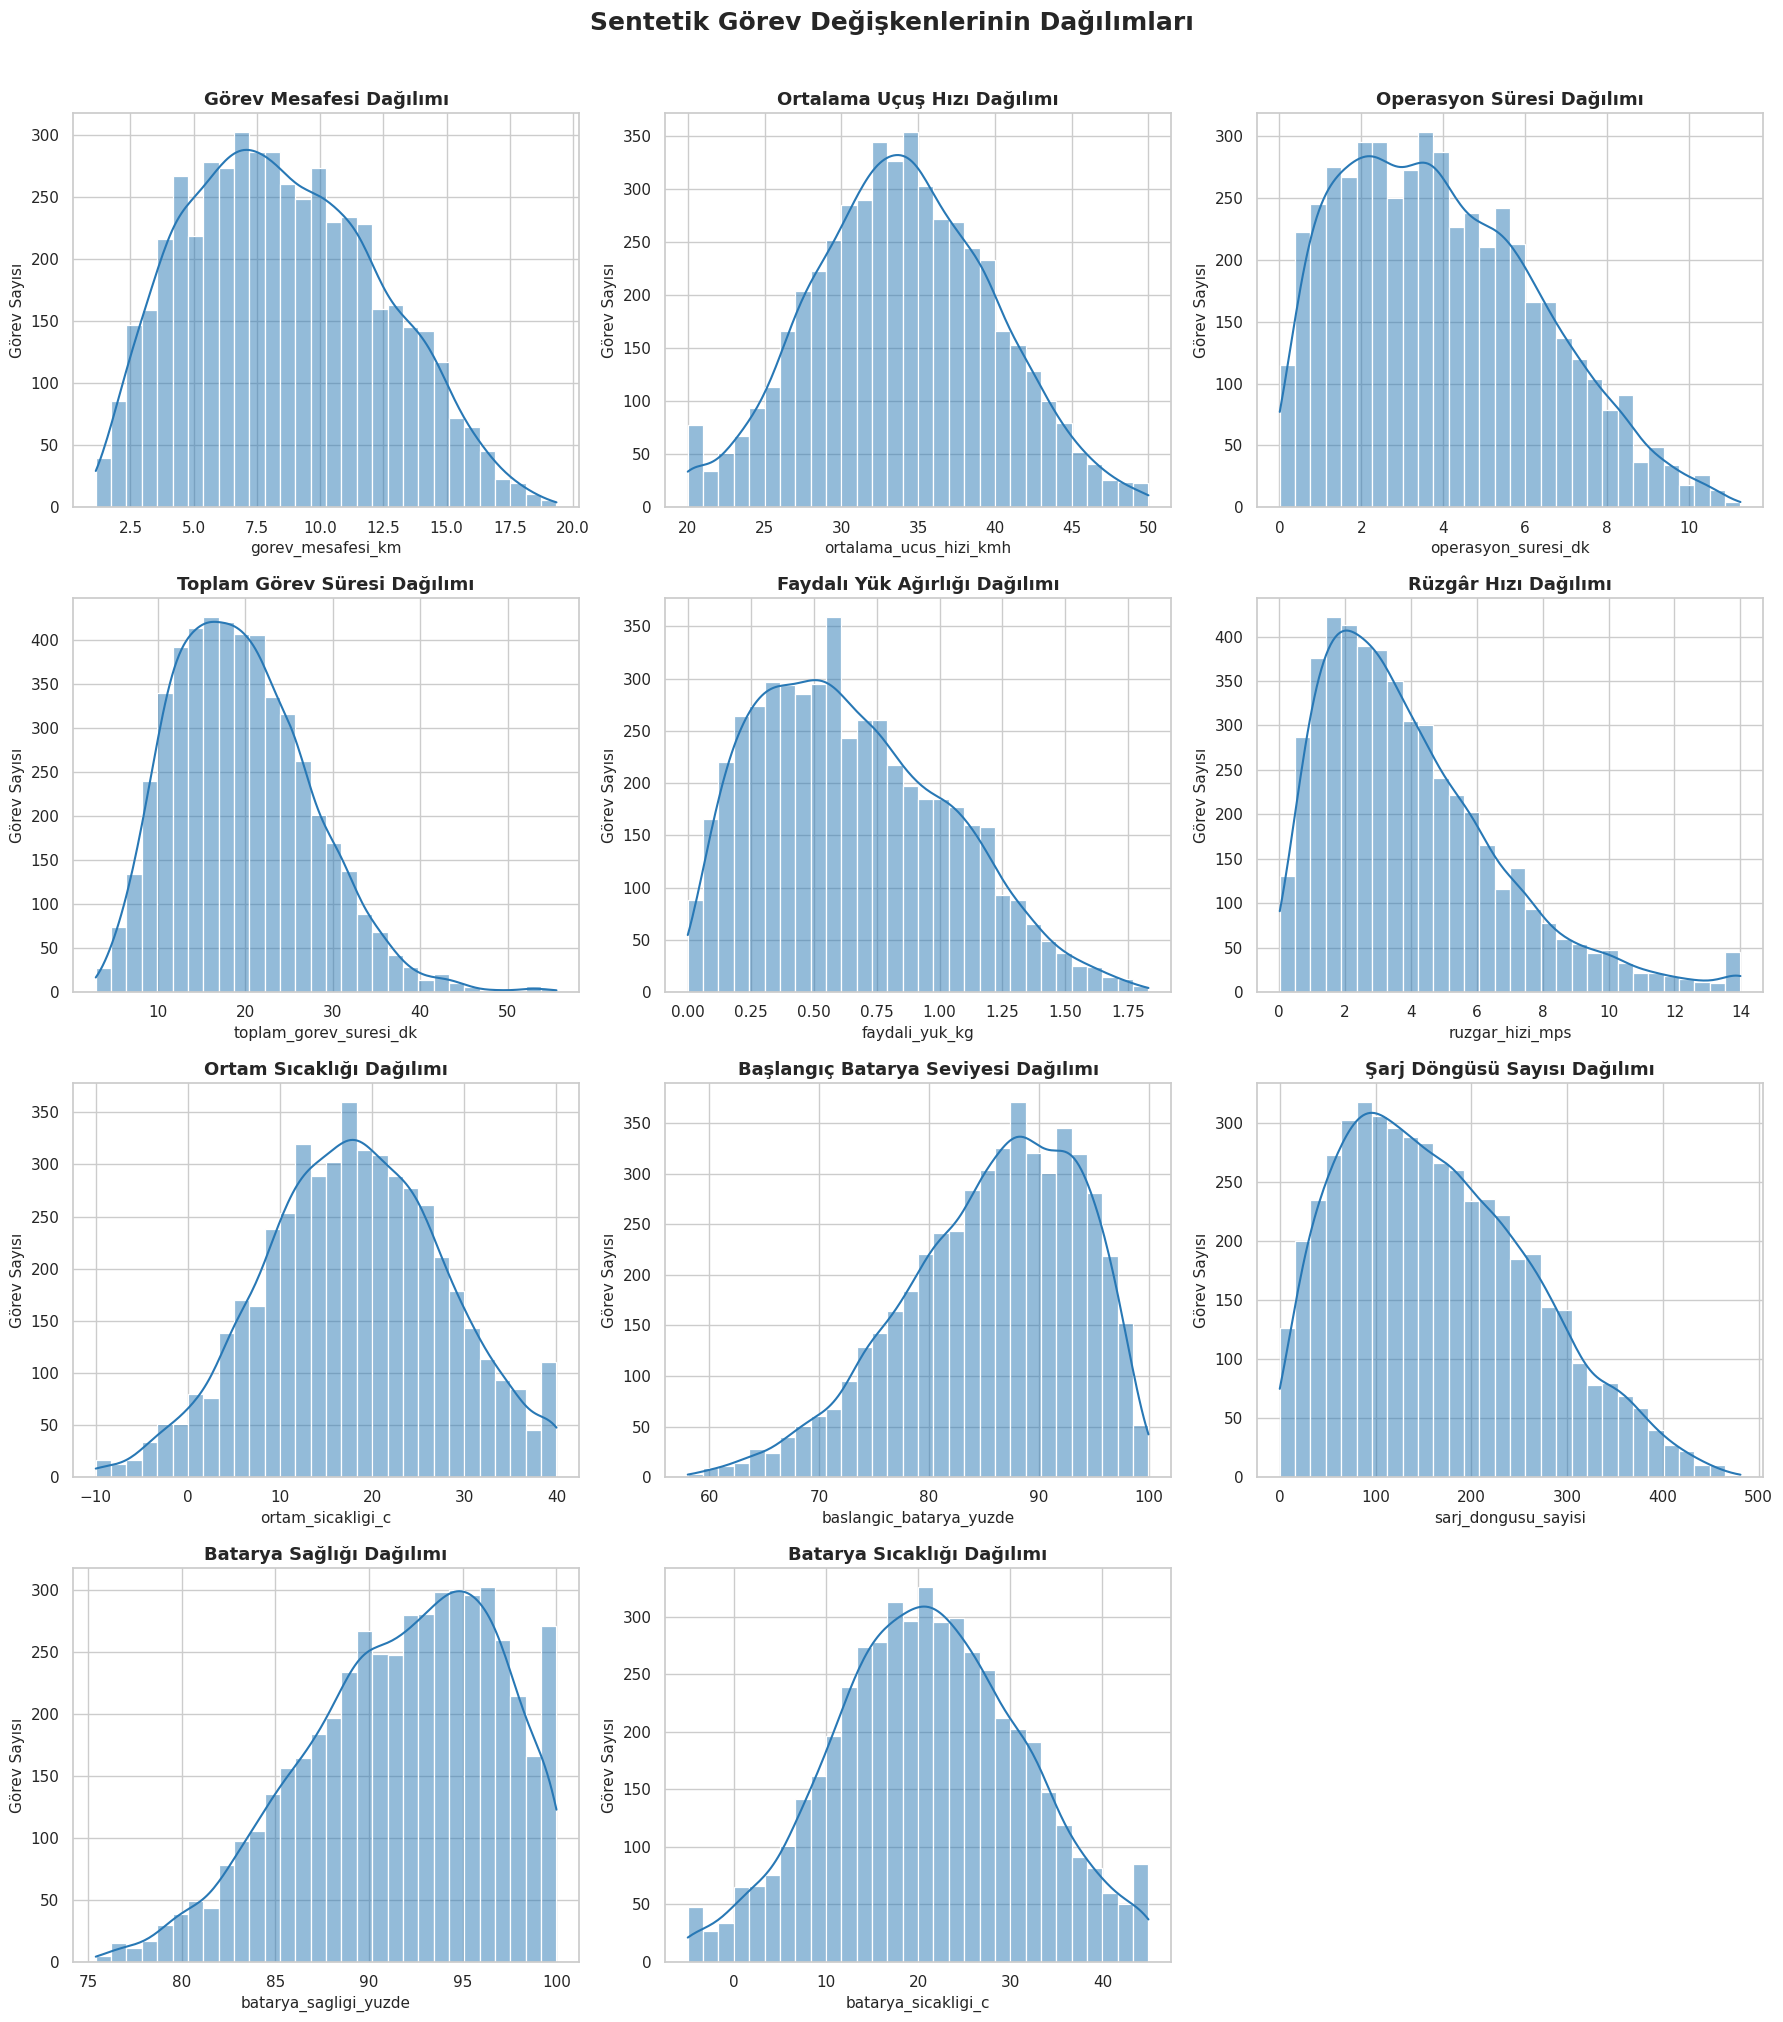

SINIR DEĞER YOĞUNLUĞU KONTROLÜ


,Kontrol,Kayıt Sayısı,Veri Kümesindeki Oranı (%)
0,Rüzgâr hızı 14 m/sn olan görevler,37,0.74
1,Ortam sıcaklığı -10 °C olan görevler,9,0.18
2,Ortam sıcaklığı 40 °C olan görevler,74,1.48
3,Uçuş hızı 20 km/sa olan görevler,55,1.10
4,Uçuş hızı 50 km/sa olan görevler,15,0.30
5,Batarya sağlığı %100 olan görevler,160,3.20
6,Batarya sıcaklığı -5 °C olan görevler,30,0.60
7,Batarya sıcaklığı 45 °C olan görevler,46,0.92


In [6]:
# Dağılımı incelenecek temel değişkenler ve grafik başlıkları tanımlanıyor.
dagilim_degisenleri = {
    "gorev_mesafesi_km": "Görev Mesafesi Dağılımı",
    "ortalama_ucus_hizi_kmh": "Ortalama Uçuş Hızı Dağılımı",
    "operasyon_suresi_dk": "Operasyon Süresi Dağılımı",
    "toplam_gorev_suresi_dk": "Toplam Görev Süresi Dağılımı",
    "faydali_yuk_kg": "Faydalı Yük Ağırlığı Dağılımı",
    "ruzgar_hizi_mps": "Rüzgâr Hızı Dağılımı",
    "ortam_sicakligi_c": "Ortam Sıcaklığı Dağılımı",
    "baslangic_batarya_yuzde": "Başlangıç Batarya Seviyesi Dağılımı",
    "sarj_dongusu_sayisi": "Şarj Döngüsü Sayısı Dağılımı",
    "batarya_sagligi_yuzde": "Batarya Sağlığı Dağılımı",
    "batarya_sicakligi_c": "Batarya Sıcaklığı Dağılımı"
}

# Değişken dağılımlarının birlikte gösterilmesi için grafik alanı oluşturuluyor.
sekil, eksenler = plt.subplots(4, 3, figsize=(18, 20))
eksenler = eksenler.flatten()

# Her değişken için histogram ve yoğunluk eğrisi çiziliyor.
for sira, (sutun, baslik) in enumerate(dagilim_degisenleri.items()):
    sns.histplot(
        data=gorev_verileri,
        x=sutun,
        bins=30,
        kde=True,
        color="#2878B5",
        edgecolor="white",
        ax=eksenler[sira]
    )

    eksenler[sira].set_title(baslik)
    eksenler[sira].set_xlabel(sutun)
    eksenler[sira].set_ylabel("Görev Sayısı")

# Kullanılmayan son grafik alanı gizleniyor.
for bos_eksen in eksenler[len(dagilim_degisenleri):]:
    bos_eksen.set_visible(False)

sekil.suptitle(
    "Sentetik Görev Değişkenlerinin Dağılımları",
    fontsize=18,
    fontweight="bold",
    y=1.01
)

plt.tight_layout()
plt.show()

# Alt ve üst sınır değerlerindeki olası veri yığılmaları sayısal olarak kontrol ediliyor.
sinir_kontrol_sonuclari = pd.DataFrame({
    "Kontrol": [
        "Rüzgâr hızı 14 m/sn olan görevler",
        "Ortam sıcaklığı -10 °C olan görevler",
        "Ortam sıcaklığı 40 °C olan görevler",
        "Uçuş hızı 20 km/sa olan görevler",
        "Uçuş hızı 50 km/sa olan görevler",
        "Batarya sağlığı %100 olan görevler",
        "Batarya sıcaklığı -5 °C olan görevler",
        "Batarya sıcaklığı 45 °C olan görevler"
    ],
    "Kayıt Sayısı": [
        (gorev_verileri["ruzgar_hizi_mps"] == 14.0).sum(),
        (gorev_verileri["ortam_sicakligi_c"] == -10.0).sum(),
        (gorev_verileri["ortam_sicakligi_c"] == 40.0).sum(),
        (gorev_verileri["ortalama_ucus_hizi_kmh"] == 20.0).sum(),
        (gorev_verileri["ortalama_ucus_hizi_kmh"] == 50.0).sum(),
        (gorev_verileri["batarya_sagligi_yuzde"] == 100.0).sum(),
        (gorev_verileri["batarya_sicakligi_c"] == -5.0).sum(),
        (gorev_verileri["batarya_sicakligi_c"] == 45.0).sum()
    ]
})

sinir_kontrol_sonuclari["Veri Kümesindeki Oranı (%)"] = (
    sinir_kontrol_sonuclari["Kayıt Sayısı"]
    / KAYIT_SAYISI
    * 100
).round(2)

print("SINIR DEĞER YOĞUNLUĞU KONTROLÜ")
print("=" * 50)
display(sinir_kontrol_sonuclari)


## 2. Görev Enerjisi Hedef Değişkeninin Oluşturulması

Makine öğrenmesi modelleri tarafından tahmin edilecek hedef değişken, görevin tamamlanması için ihtiyaç duyulan enerji miktarıdır. Bu değer `gerekli_enerji_wh` adıyla ve watt-saat birimiyle oluşturulmuştur.

Enerji ihtiyacının hesaplanmasında aşağıdaki etkiler dikkate alınmıştır:

- Toplam görev süresi,
- Faydalı yük ağırlığı,
- Rüzgâr hızının doğrusal olmayan etkisi,
- Rüzgâr hızı ile faydalı yük arasındaki etkileşim,
- Ortam sıcaklığının ideal sıcaklıktan uzaklaşması,
- Batarya sıcaklığının ideal çalışma sıcaklığından uzaklaşması,
- Ortalama uçuş hızının verimli kabul edilen hızdan uzaklaşması,
- Operasyon sırasında oluşan ek enerji ihtiyacı.

Değişkenler arasındaki ilişkilerin tamamen kesin ve kusursuz olmaması için enerji değerlerine kontrollü rastgele gürültü eklenmiştir. Böylece gerçek çalışma koşullarındaki ölçüm farklılıkları ve modellenmeyen dış etkiler temsil edilmeye çalışılmıştır.

Kullanılan matematiksel ilişkiler, gerçek bir Droneport veya İHA sisteminin teknik değerleri değildir. Bu ilişkiler yalnızca kavram kanıtlama çalışmasında kullanılacak sentetik veri kümesinin oluşturulması amacıyla belirlenen simülasyon varsayımlarıdır.



In [7]:
# Enerji hesabında kullanılacak ideal çalışma değerleri tanımlanıyor.
IDEAL_UCUS_HIZI_KMH = 34.0
IDEAL_ORTAM_SICAKLIGI_C = 22.0
IDEAL_BATARYA_SICAKLIGI_C = 25.0

# Her görev için temel enerji tüketim oranı tanımlanıyor.
# Bu değer, görev süresine bağlı temel sistem tüketimini temsil ediyor.
temel_tuketim_orani = 6.5

# Faydalı yükün görev süresi boyunca oluşturduğu ek enerji etkisi hesaplanıyor.
faydali_yuk_etkisi = (
    1.20 * gorev_verileri["faydali_yuk_kg"]
)

# Rüzgâr hızının enerji ihtiyacı üzerindeki doğrusal olmayan etkisi hesaplanıyor.
ruzgar_etkisi = (
    0.025 * gorev_verileri["ruzgar_hizi_mps"] ** 2
)

# Yüksek rüzgâr ve ağır faydalı yükün birlikte oluşturduğu ek etki hesaplanıyor.
ruzgar_yuk_etkilesimi = (
    0.080
    * gorev_verileri["ruzgar_hizi_mps"]
    * gorev_verileri["faydali_yuk_kg"]
)

# Ortam sıcaklığının ideal sıcaklıktan uzaklaşmasına bağlı enerji cezası hesaplanıyor.
ortam_sicakligi_etkisi = (
    0.0025
    * (
        gorev_verileri["ortam_sicakligi_c"]
        - IDEAL_ORTAM_SICAKLIGI_C
    ) ** 2
)

# Batarya sıcaklığının ideal değerden uzaklaşmasına bağlı verim kaybı hesaplanıyor.
batarya_sicakligi_etkisi = (
    0.0020
    * (
        gorev_verileri["batarya_sicakligi_c"]
        - IDEAL_BATARYA_SICAKLIGI_C
    ) ** 2
)

# Uçuş hızının verimli kabul edilen değerden uzaklaşmasının etkisi hesaplanıyor.
ucus_hizi_etkisi = (
    0.008
    * (
        gorev_verileri["ortalama_ucus_hizi_kmh"]
        - IDEAL_UCUS_HIZI_KMH
    ) ** 2
)

# Görev süresine bağlı toplam enerji ihtiyacının gürültüsüz bölümü hesaplanıyor.
gurultusuz_enerji_wh = (
    15.0
    + gorev_verileri["toplam_gorev_suresi_dk"]
    * (
        temel_tuketim_orani
        + faydali_yuk_etkisi
        + ruzgar_etkisi
        + ruzgar_yuk_etkilesimi
        + ortam_sicakligi_etkisi
        + batarya_sicakligi_etkisi
        + ucus_hizi_etkisi
    )
    + 0.80 * gorev_verileri["operasyon_suresi_dk"]
)

# Ölçüm farklılıklarını ve modellenmeyen dış etkileri temsil eden gürültü oluşturuluyor.
# Gürültü miktarı, görevin enerji ihtiyacı arttıkça kontrollü şekilde büyüyor.
enerji_gurultusu = np.random.normal(
    loc=0.0,
    scale=4.0 + (0.03 * gurultusuz_enerji_wh),
    size=KAYIT_SAYISI
)

# Gürültü enerji değerlerine ekleniyor ve negatif sonuç oluşması engelleniyor.
gerekli_enerji_wh = np.maximum(
    gurultusuz_enerji_wh + enerji_gurultusu,
    20.0
)

# Hesaplanan hedef değişken veri kümesine ekleniyor.
gorev_verileri["gerekli_enerji_wh"] = np.round(
    gerekli_enerji_wh,
    2
)

# Oluşturulan enerji değerlerinin temel istatistikleri hazırlanıyor.
enerji_ozeti = gorev_verileri["gerekli_enerji_wh"].describe().to_frame()
enerji_ozeti.columns = ["Değer"]
enerji_ozeti.index = [
    "Kayıt Sayısı",
    "Ortalama",
    "Standart Sapma",
    "En Düşük",
    "%25",
    "Medyan",
    "%75",
    "En Yüksek"
]
enerji_ozeti["Değer"] = enerji_ozeti["Değer"].round(2)

print("Görev enerjisi hedef değişkeni başarıyla oluşturuldu.")
print("-" * 60)
print(f"Veri kümesinin yeni boyutu: {gorev_verileri.shape}")
print(
    "Nominal batarya kapasitesini aşan görev sayısı: "
    f"{(gorev_verileri['gerekli_enerji_wh'] > NOMINAL_BATARYA_KAPASITESI_WH).sum()}"
)

print("\nGEREKLİ ENERJİ DEĞİŞKENİNİN İSTATİSTİKSEL ÖZETİ")
print("=" * 60)
display(enerji_ozeti)

print("\nHEDEF DEĞİŞKEN EKLENDİKTEN SONRA İLK BEŞ GÖREV")
print("=" * 60)
display(
    gorev_verileri[
        [
            "gorev_no",
            "toplam_gorev_suresi_dk",
            "faydali_yuk_kg",
            "ruzgar_hizi_mps",
            "ortam_sicakligi_c",
            "gerekli_enerji_wh"
        ]
    ].head()
)


Görev enerjisi hedef değişkeni başarıyla oluşturuldu.
------------------------------------------------------------
Veri kümesinin yeni boyutu: (5000, 13)
Nominal batarya kapasitesini aşan görev sayısı: 1

GEREKLİ ENERJİ DEĞİŞKENİNİN İSTATİSTİKSEL ÖZETİ


,Değer
Kayıt Sayısı,5000.00
Ortalama,193.42
Standart Sapma,79.27
En Düşük,37.40
%25,136.17
Medyan,182.07
%75,237.57
En Yüksek,661.41



HEDEF DEĞİŞKEN EKLENDİKTEN SONRA İLK BEŞ GÖREV


,gorev_no,toplam_gorev_suresi_dk,faydali_yuk_kg,ruzgar_hizi_mps,ortam_sicakligi_c,gerekli_enerji_wh
0,1,15.48,0.57,2.14,8.62,148.26
1,2,32.96,0.84,8.93,9.60,418.59
2,3,25.31,0.64,0.63,4.82,268.61
3,4,17.87,0.15,2.34,3.29,172.56
4,5,35.39,0.75,4.55,10.21,323.47


### 2.1. Hedef Değişkenin Dağılım ve Tutarlılık Kontrolü

Oluşturulan enerji hedef değişkeninin dağılımı incelenmiş ve görev süresiyle olan ilişkisi görselleştirilmiştir. Ayrıca en yüksek enerji ihtiyacına sahip görevler ayrıntılı olarak kontrol edilmiştir.

Bu incelemeyle yüksek enerji değerlerinin yalnızca rastgele gürültüden kaynaklanıp kaynaklanmadığının ve zorlu görev koşullarıyla açıklanıp açıklanamadığının belirlenmesi amaçlanmıştır. Nominal batarya kapasitesini aşan görevler veri kümesinden doğrudan çıkarılmamıştır. Bu tür görevler, karar destek sisteminin uygun olmayan senaryoları tanımlayabilmesi açısından veri kümesinde korunmuştur.


ENERJİ YÜZDELİK DEĞERLERİ


,Yüzdelik,Gerekli Enerji (Wh)
0,%1,61.65
1,%5,86.45
2,%25,136.17
3,%50,182.07
4,%75,237.57
5,%95,337.24
6,%99,446.24



YÜKSEK ENERJİ İHTİYACINA SAHİP GÖREVLER


,Enerji Koşulu,Görev Sayısı,Veri Kümesindeki Oranı (%)
0,300 Wh değerini aşan görevler,454,9.08
1,400 Wh değerini aşan görevler,99,1.98
2,500 Wh değerini aşan görevler,15,0.30
3,600 Wh değerini aşan görevler,1,0.02


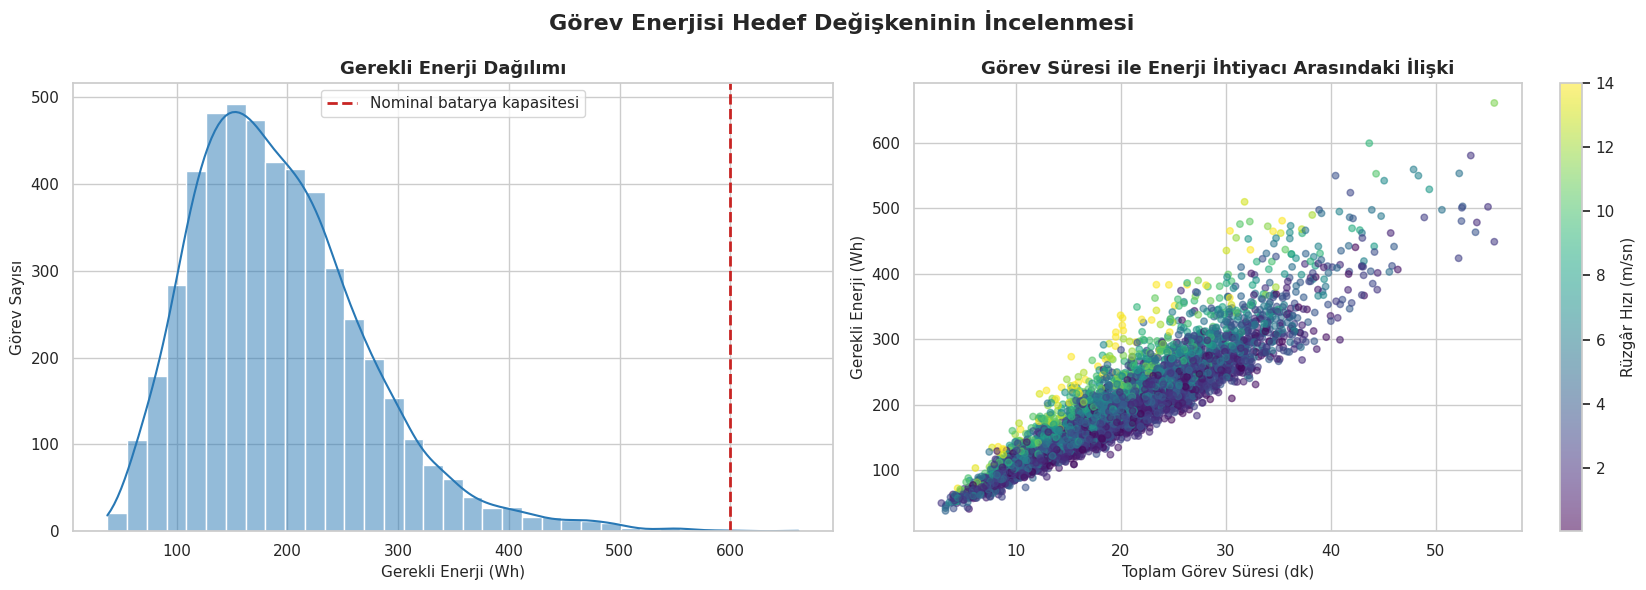


EN YÜKSEK ENERJİ İHTİYACINA SAHİP 10 GÖREV


,gorev_no,gorev_mesafesi_km,ortalama_ucus_hizi_kmh,operasyon_suresi_dk,toplam_gorev_suresi_dk,faydali_yuk_kg,ruzgar_hizi_mps,ortam_sicakligi_c,batarya_sicakligi_c,gerekli_enerji_wh
1172,1173,16.76,20.00,5.30,55.59,0.29,11.22,26.69,29.68,661.41
1802,1803,13.91,22.37,6.38,43.68,1.30,9.21,25.55,33.12,599.86
4202,4203,18.66,23.36,5.43,53.35,0.54,2.19,0.46,2.99,581.00
2903,2904,15.25,20.00,2.15,47.90,1.27,5.98,29.16,35.75,559.69
915,916,15.78,20.09,5.13,52.25,1.13,5.35,24.04,25.30,553.69
3215,3216,13.76,21.25,5.47,44.33,1.11,10.15,26.61,26.39,553.15
2508,2509,11.67,22.30,9.07,40.47,1.10,3.53,-4.42,-3.92,550.20
3301,3302,13.71,20.14,7.53,48.36,0.93,6.32,26.55,37.63,550.18
4281,4282,15.30,21.31,2.00,45.10,1.28,6.69,10.53,14.30,542.55
3900,3901,16.98,25.22,9.02,49.40,0.21,7.52,5.01,11.10,529.26


In [8]:
# Gerekli enerji değişkeninin seçili yüzdelik değerleri hesaplanıyor.
enerji_yuzdelikleri = gorev_verileri[
    "gerekli_enerji_wh"
].quantile(
    [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

enerji_yuzdelik_tablosu = pd.DataFrame({
    "Yüzdelik": [
        "%1",
        "%5",
        "%25",
        "%50",
        "%75",
        "%95",
        "%99"
    ],
    "Gerekli Enerji (Wh)": enerji_yuzdelikleri.values.round(2)
})

# Farklı enerji seviyelerindeki görev sayıları hesaplanıyor.
enerji_seviye_tablosu = pd.DataFrame({
    "Enerji Koşulu": [
        "300 Wh değerini aşan görevler",
        "400 Wh değerini aşan görevler",
        "500 Wh değerini aşan görevler",
        "600 Wh değerini aşan görevler"
    ],
    "Görev Sayısı": [
        (gorev_verileri["gerekli_enerji_wh"] > 300).sum(),
        (gorev_verileri["gerekli_enerji_wh"] > 400).sum(),
        (gorev_verileri["gerekli_enerji_wh"] > 500).sum(),
        (gorev_verileri["gerekli_enerji_wh"] > 600).sum()
    ]
})

enerji_seviye_tablosu["Veri Kümesindeki Oranı (%)"] = (
    enerji_seviye_tablosu["Görev Sayısı"]
    / KAYIT_SAYISI
    * 100
).round(2)

print("ENERJİ YÜZDELİK DEĞERLERİ")
print("=" * 55)
display(enerji_yuzdelik_tablosu)

print("\nYÜKSEK ENERJİ İHTİYACINA SAHİP GÖREVLER")
print("=" * 55)
display(enerji_seviye_tablosu)

# Enerji dağılımı ve görev süresiyle ilişkisi birlikte görselleştiriliyor.
sekil, eksenler = plt.subplots(1, 2, figsize=(17, 6))

sns.histplot(
    data=gorev_verileri,
    x="gerekli_enerji_wh",
    bins=35,
    kde=True,
    color="#2878B5",
    edgecolor="white",
    ax=eksenler[0]
)

eksenler[0].axvline(
    NOMINAL_BATARYA_KAPASITESI_WH,
    color="#C82423",
    linestyle="--",
    linewidth=2,
    label="Nominal batarya kapasitesi"
)
eksenler[0].set_title("Gerekli Enerji Dağılımı")
eksenler[0].set_xlabel("Gerekli Enerji (Wh)")
eksenler[0].set_ylabel("Görev Sayısı")
eksenler[0].legend()

sacilim_grafigi = eksenler[1].scatter(
    gorev_verileri["toplam_gorev_suresi_dk"],
    gorev_verileri["gerekli_enerji_wh"],
    c=gorev_verileri["ruzgar_hizi_mps"],
    cmap="viridis",
    alpha=0.55,
    s=22
)

eksenler[1].set_title("Görev Süresi ile Enerji İhtiyacı Arasındaki İlişki")
eksenler[1].set_xlabel("Toplam Görev Süresi (dk)")
eksenler[1].set_ylabel("Gerekli Enerji (Wh)")

renk_cubugu = sekil.colorbar(
    sacilim_grafigi,
    ax=eksenler[1]
)
renk_cubugu.set_label("Rüzgâr Hızı (m/sn)")

sekil.suptitle(
    "Görev Enerjisi Hedef Değişkeninin İncelenmesi",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# En yüksek enerji ihtiyacına sahip on görev ayrıntılı olarak görüntüleniyor.
en_yuksek_enerjili_gorevler = gorev_verileri.nlargest(
    10,
    "gerekli_enerji_wh"
)[
    [
        "gorev_no",
        "gorev_mesafesi_km",
        "ortalama_ucus_hizi_kmh",
        "operasyon_suresi_dk",
        "toplam_gorev_suresi_dk",
        "faydali_yuk_kg",
        "ruzgar_hizi_mps",
        "ortam_sicakligi_c",
        "batarya_sicakligi_c",
        "gerekli_enerji_wh"
    ]
]

print("\nEN YÜKSEK ENERJİ İHTİYACINA SAHİP 10 GÖREV")
print("=" * 55)
display(en_yuksek_enerjili_gorevler)


### 2.2. Görev Değişkenleri ile Enerji İhtiyacı Arasındaki İlişkilerin İncelenmesi

Görev değişkenlerinin enerji ihtiyacıyla olan doğrusal ilişkileri korelasyon analizi kullanılarak incelenmiştir. Korelasyon katsayısının mutlak değeri büyüdükçe iki değişken arasındaki doğrusal ilişkinin gücü artmaktadır.

Bununla birlikte düşük korelasyon, bir değişkenin enerji ihtiyacı üzerinde hiçbir etkisi olmadığı anlamına gelmez. Sıcaklık ve uçuş hızı gibi bazı değişkenler enerji ihtiyacını ideal değerden uzaklaşmaya bağlı ve doğrusal olmayan biçimde etkilemektedir. Bu nedenle korelasyon sonuçları, sonraki aşamalarda uygulanacak makine öğrenmesi modelleriyle birlikte değerlendirilecektir.



DEĞİŞKENLERİN GEREKLİ ENERJİ İLE KORELASYONU


,Değişken,Enerji ile Korelasyon
0,toplam_gorev_suresi_dk,0.9223
1,gorev_mesafesi_km,0.7720
2,ortalama_ucus_hizi_kmh,-0.3449
3,operasyon_suresi_dk,0.2942
4,ruzgar_hizi_mps,0.2185
5,faydali_yuk_kg,0.1476
6,ortam_sicakligi_c,-0.1107
7,batarya_sicakligi_c,-0.0950


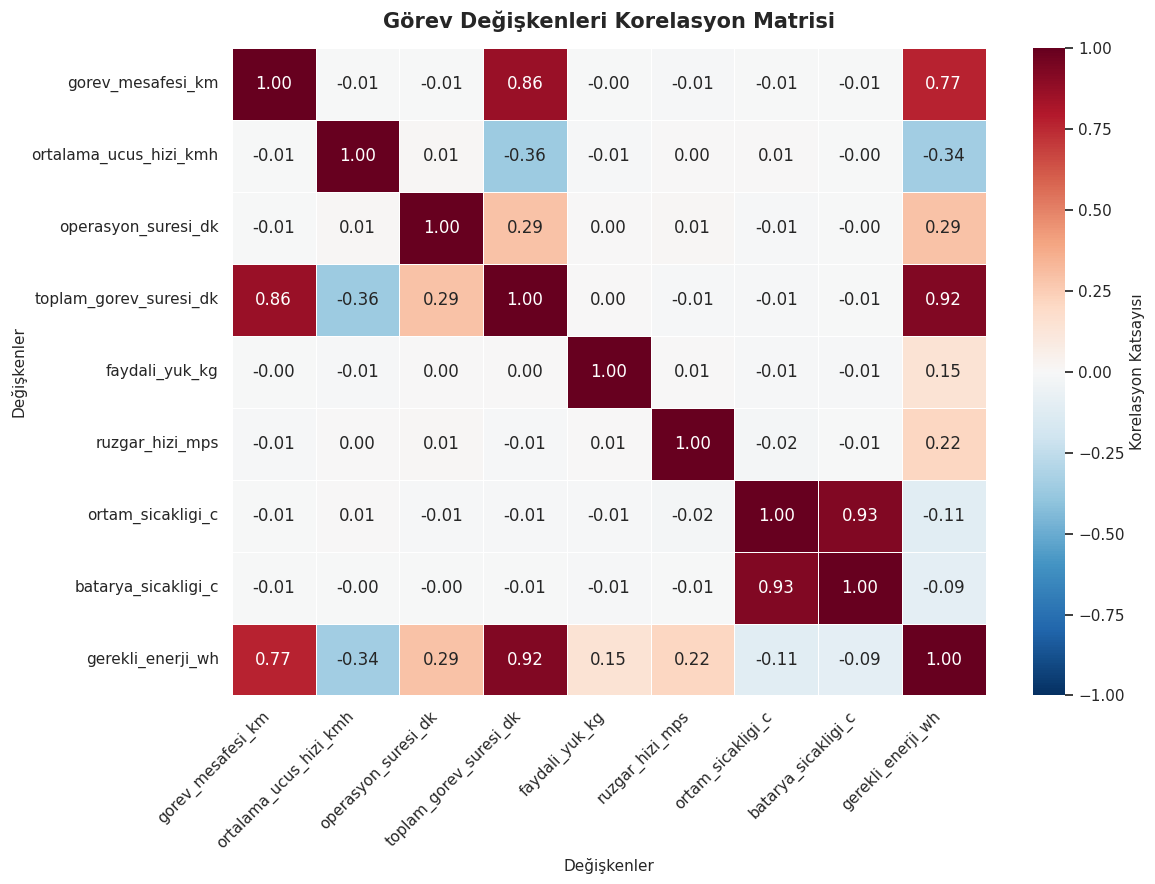

In [9]:
# Korelasyon analizinde kullanılacak sayısal değişkenler seçiliyor.
korelasyon_sutunlari = [
    "gorev_mesafesi_km",
    "ortalama_ucus_hizi_kmh",
    "operasyon_suresi_dk",
    "toplam_gorev_suresi_dk",
    "faydali_yuk_kg",
    "ruzgar_hizi_mps",
    "ortam_sicakligi_c",
    "batarya_sicakligi_c",
    "gerekli_enerji_wh"
]

# Seçilen değişkenlerin korelasyon matrisi hesaplanıyor.
korelasyon_matrisi = gorev_verileri[
    korelasyon_sutunlari
].corr()

# Her değişkenin gerekli enerjiyle korelasyonu ayrı bir tabloda hazırlanıyor.
enerji_korelasyonlari = (
    korelasyon_matrisi["gerekli_enerji_wh"]
    .drop("gerekli_enerji_wh")
    .sort_values(key=np.abs, ascending=False)
    .reset_index()
)

enerji_korelasyonlari.columns = [
    "Değişken",
    "Enerji ile Korelasyon"
]

enerji_korelasyonlari["Enerji ile Korelasyon"] = (
    enerji_korelasyonlari["Enerji ile Korelasyon"].round(4)
)

print("DEĞİŞKENLERİN GEREKLİ ENERJİ İLE KORELASYONU")
print("=" * 60)
display(enerji_korelasyonlari)

# Korelasyon matrisi ısı haritası şeklinde görselleştiriliyor.
plt.figure(figsize=(12, 9))

sns.heatmap(
    korelasyon_matrisi,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={
        "label": "Korelasyon Katsayısı"
    }
)

plt.title(
    "Görev Değişkenleri Korelasyon Matrisi",
    fontsize=15,
    fontweight="bold",
    pad=15
)
plt.xlabel("Değişkenler")
plt.ylabel("Değişkenler")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### 2.3. Doğrusal Olmayan Etkilerin İncelenmesi

Pearson korelasyon katsayısı temel olarak doğrusal ilişkileri göstermektedir. Bu nedenle ideal çalışma değerinden uzaklaşmaya bağlı etkiler, ham sıcaklık ve hız değişkenlerinin korelasyonlarında yeterince görünmeyebilir.

Ortam sıcaklığı, batarya sıcaklığı ve ortalama uçuş hızı için ideal değerlerden karesel sapmalar hesaplanmıştır. Ayrıca rüzgâr hızı ile faydalı yükün birlikte oluşturduğu etkiyi incelemek amacıyla etkileşim değişkenleri oluşturulmuştur.

Bu değişkenler yalnızca veri üretim mantığının doğrulanması amacıyla geçici olarak hesaplanmıştır. Ana veri kümesine yeni model girdileri olarak henüz eklenmemiştir.


DOĞRUSAL OLMAYAN VE ETKİLEŞİMLİ DEĞİŞKENLERİN ANALİZİ


,İncelenen Etki,Enerji ile Korelasyon
0,Rüzgâr ve faydalı yük etkileşimi,0.2537
1,Rüzgâr hızının karesi,0.2154
2,Ortam sıcaklığının ideal değerden karesel sapması,0.2085
3,Batarya sıcaklığının ideal değerden karesel sa...,0.1885
4,Uçuş hızının ideal değerden karesel sapması,0.1711


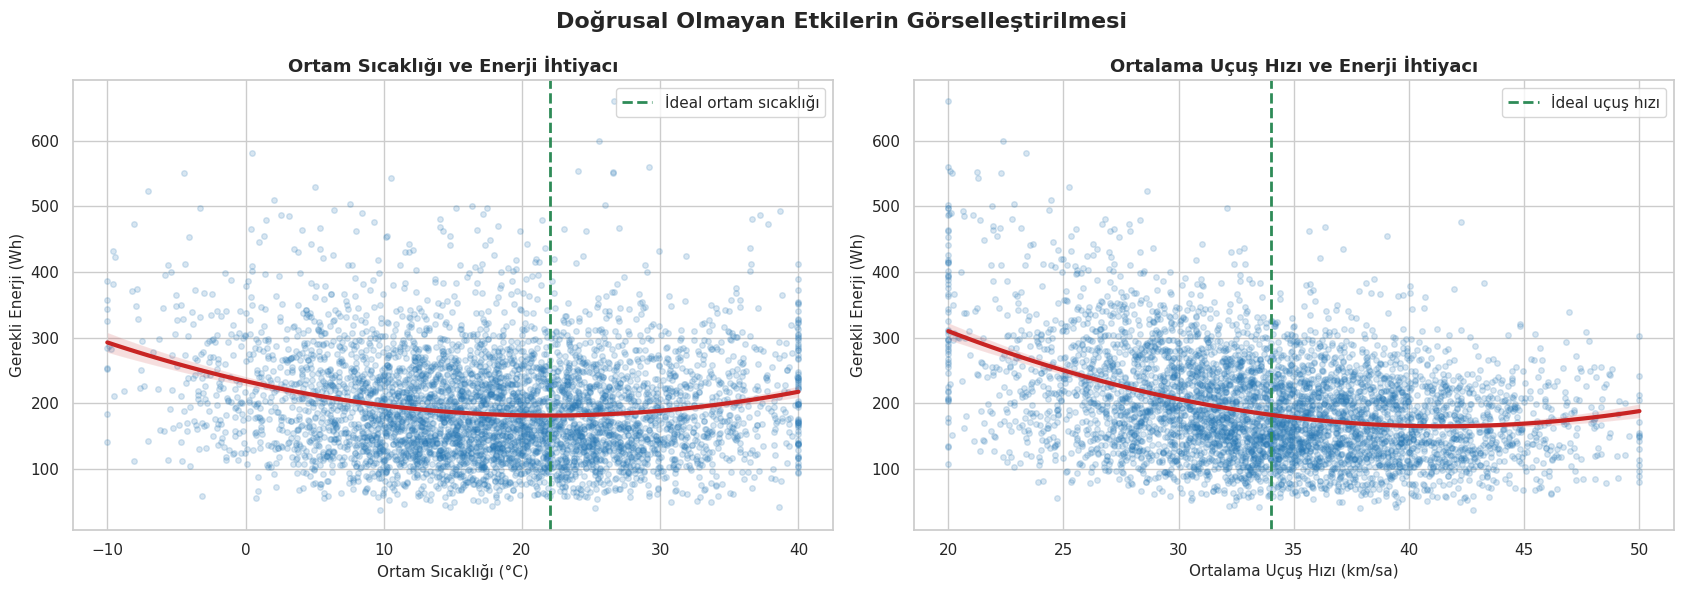

In [10]:
# Doğrusal olmayan ve etkileşimli etkileri incelemek için geçici analiz değişkenleri oluşturuluyor.
dogrusal_olmayan_analiz = pd.DataFrame({
    "Ortam sıcaklığının ideal değerden karesel sapması": (
        gorev_verileri["ortam_sicakligi_c"]
        - IDEAL_ORTAM_SICAKLIGI_C
    ) ** 2,

    "Batarya sıcaklığının ideal değerden karesel sapması": (
        gorev_verileri["batarya_sicakligi_c"]
        - IDEAL_BATARYA_SICAKLIGI_C
    ) ** 2,

    "Uçuş hızının ideal değerden karesel sapması": (
        gorev_verileri["ortalama_ucus_hizi_kmh"]
        - IDEAL_UCUS_HIZI_KMH
    ) ** 2,

    "Rüzgâr hızının karesi": (
        gorev_verileri["ruzgar_hizi_mps"] ** 2
    ),

    "Rüzgâr ve faydalı yük etkileşimi": (
        gorev_verileri["ruzgar_hizi_mps"]
        * gorev_verileri["faydali_yuk_kg"]
    ),

    "Gerekli enerji": gorev_verileri["gerekli_enerji_wh"]
})

# Oluşturulan geçici değişkenlerin gerekli enerjiyle korelasyonları hesaplanıyor.
dogrusal_olmayan_korelasyonlar = (
    dogrusal_olmayan_analiz
    .corr()["Gerekli enerji"]
    .drop("Gerekli enerji")
    .sort_values(key=np.abs, ascending=False)
    .reset_index()
)

dogrusal_olmayan_korelasyonlar.columns = [
    "İncelenen Etki",
    "Enerji ile Korelasyon"
]

dogrusal_olmayan_korelasyonlar["Enerji ile Korelasyon"] = (
    dogrusal_olmayan_korelasyonlar[
        "Enerji ile Korelasyon"
    ].round(4)
)

print("DOĞRUSAL OLMAYAN VE ETKİLEŞİMLİ DEĞİŞKENLERİN ANALİZİ")
print("=" * 75)
display(dogrusal_olmayan_korelasyonlar)

# Ortam sıcaklığı ve uçuş hızının enerjiyle ilişkisi görselleştiriliyor.
sekil, eksenler = plt.subplots(1, 2, figsize=(17, 6))

sns.regplot(
    data=gorev_verileri,
    x="ortam_sicakligi_c",
    y="gerekli_enerji_wh",
    order=2,
    scatter_kws={
        "alpha": 0.18,
        "s": 16,
        "color": "#2878B5"
    },
    line_kws={
        "color": "#C82423",
        "linewidth": 3
    },
    ax=eksenler[0]
)

eksenler[0].axvline(
    IDEAL_ORTAM_SICAKLIGI_C,
    color="#2E8B57",
    linestyle="--",
    linewidth=2,
    label="İdeal ortam sıcaklığı"
)
eksenler[0].set_title("Ortam Sıcaklığı ve Enerji İhtiyacı")
eksenler[0].set_xlabel("Ortam Sıcaklığı (°C)")
eksenler[0].set_ylabel("Gerekli Enerji (Wh)")
eksenler[0].legend()

sns.regplot(
    data=gorev_verileri,
    x="ortalama_ucus_hizi_kmh",
    y="gerekli_enerji_wh",
    order=2,
    scatter_kws={
        "alpha": 0.18,
        "s": 16,
        "color": "#2878B5"
    },
    line_kws={
        "color": "#C82423",
        "linewidth": 3
    },
    ax=eksenler[1]
)

eksenler[1].axvline(
    IDEAL_UCUS_HIZI_KMH,
    color="#2E8B57",
    linestyle="--",
    linewidth=2,
    label="İdeal uçuş hızı"
)
eksenler[1].set_title("Ortalama Uçuş Hızı ve Enerji İhtiyacı")
eksenler[1].set_xlabel("Ortalama Uçuş Hızı (km/sa)")
eksenler[1].set_ylabel("Gerekli Enerji (Wh)")
eksenler[1].legend()

sekil.suptitle(
    "Doğrusal Olmayan Etkilerin Görselleştirilmesi",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


### 2.4. Proje Dosyalarının Kalıcı Olarak Saklanması

Google Colab çalışma oturumunda oluşturulan değişkenler ve geçici dosyalar, çalışma ortamı kapatıldığında silinebilmektedir. Bu nedenle proje çıktılarının kalıcı olarak saklanabilmesi amacıyla Google Drive bağlantısı kurulmuştur.

Veri kümeleri, grafikler ve daha sonraki aşamalarda oluşturulacak makine öğrenmesi modelleri proje için ayrılan klasör yapısı içinde saklanacaktır.


In [11]:
# Google Drive bağlantısı için gerekli araçlar içe aktarılıyor.
from google.colab import drive
from IPython.display import clear_output

# Proje dosyalarının kalıcı olarak saklanması için Google Drive bağlanıyor.
drive.mount("/content/drive")

# Google Colab tarafından oluşturulan geçici bağlantı çıktısı temizleniyor.
clear_output()

print("Google Drive bağlantısı başarıyla kuruldu.")


Google Drive bağlantısı başarıyla kuruldu.


In [12]:
# Dosya ve klasör işlemleri için gerekli kütüphane içe aktarılıyor.
from pathlib import Path

# Google Drive içinde projenin ana klasörü tanımlanıyor.
PROJE_KLASORU = Path(
    "/content/drive/MyDrive/Droneport_Enerji_Optimizasyonu"
)

# Projede kullanılacak alt klasörler tanımlanıyor.
VERI_KLASORU = PROJE_KLASORU / "veri"
GRAFIK_KLASORU = PROJE_KLASORU / "grafikler"
MODEL_KLASORU = PROJE_KLASORU / "modeller"
SONUC_KLASORU = PROJE_KLASORU / "sonuclar"

# Klasörler daha önce oluşturulmadıysa oluşturuluyor.
olusturulacak_klasorler = [
    PROJE_KLASORU,
    VERI_KLASORU,
    GRAFIK_KLASORU,
    MODEL_KLASORU,
    SONUC_KLASORU
]

for klasor in olusturulacak_klasorler:
    klasor.mkdir(parents=True, exist_ok=True)

# Şu ana kadar oluşturulan hatasız temel veri kümesinin dosya yolu belirleniyor.
TEMEL_VERI_DOSYASI = (
    VERI_KLASORU / "droneport_temel_gorev_verileri.csv"
)

# Veri kümesi Türkçe karakterleri destekleyen biçimde CSV dosyasına kaydediliyor.
gorev_verileri.to_csv(
    TEMEL_VERI_DOSYASI,
    index=False,
    encoding="utf-8-sig"
)

# Kaydedilen dosya tekrar okunarak kayıt işlemi doğrulanıyor.
kaydedilen_temel_veri = pd.read_csv(
    TEMEL_VERI_DOSYASI,
    encoding="utf-8-sig"
)

# Dosyanın boyutu hesaplanıyor.
dosya_boyutu_kb = TEMEL_VERI_DOSYASI.stat().st_size / 1024

print("PROJE KLASÖRLERİ VE VERİ DOSYASI KONTROLÜ")
print("=" * 65)
print(f"Proje klasörü : {PROJE_KLASORU}")
print(f"Veri klasörü  : {VERI_KLASORU}")
print(f"Grafik klasörü: {GRAFIK_KLASORU}")
print(f"Model klasörü : {MODEL_KLASORU}")
print(f"Sonuç klasörü : {SONUC_KLASORU}")

print("\nTEMEL VERİ KÜMESİ KAYIT SONUCU")
print("=" * 65)
print(f"Dosya adı     : {TEMEL_VERI_DOSYASI.name}")
print(f"Dosya mevcut  : {TEMEL_VERI_DOSYASI.exists()}")
print(f"Dosya boyutu  : {dosya_boyutu_kb:.2f} KB")
print(f"Satır sayısı  : {kaydedilen_temel_veri.shape[0]}")
print(f"Sütun sayısı  : {kaydedilen_temel_veri.shape[1]}")

# Bellekteki ve kaydedilen veri kümelerinin aynı olup olmadığı kontrol ediliyor.
kayit_dogrulandi = gorev_verileri.reset_index(
    drop=True
).equals(
    kaydedilen_temel_veri.reset_index(drop=True)
)

print(f"Kayıt doğrulandı: {kayit_dogrulandi}")


PROJE KLASÖRLERİ VE VERİ DOSYASI KONTROLÜ
Proje klasörü : /content/drive/MyDrive/Droneport_Enerji_Optimizasyonu
Veri klasörü  : /content/drive/MyDrive/Droneport_Enerji_Optimizasyonu/veri
Grafik klasörü: /content/drive/MyDrive/Droneport_Enerji_Optimizasyonu/grafikler
Model klasörü : /content/drive/MyDrive/Droneport_Enerji_Optimizasyonu/modeller
Sonuç klasörü : /content/drive/MyDrive/Droneport_Enerji_Optimizasyonu/sonuclar

TEMEL VERİ KÜMESİ KAYIT SONUCU
Dosya adı     : droneport_temel_gorev_verileri.csv
Dosya mevcut  : True
Dosya boyutu  : 343.33 KB
Satır sayısı  : 5000
Sütun sayısı  : 13
Kayıt doğrulandı: True


## 3. Kontrollü Veri Kalitesi Sorunlarının Oluşturulması

Gerçek veri toplama süreçlerinde sensör bağlantısının geçici olarak kesilmesi, veri aktarımının tamamlanamaması veya ölçüm hataları nedeniyle eksik ve geçersiz değerlerle karşılaşılabilmektedir.

Bu çalışmada gerçek cihaz verisi kullanılmadığı için veri ön işleme sürecinin test edilebilmesi amacıyla, oluşturulan temel veri kümesinin bir kopyasına kontrollü veri kalitesi sorunları eklenmiştir. Temel veri kümesi değiştirilmeden korunmuş ve sorunlu kayıtlar ayrı bir ham veri dosyasına kaydedilmiştir.

Bazı giriş değişkenlerinde düşük oranda eksik değer oluşturulmuş, ayrıca sınırlı sayıdaki kayda fiziksel olarak geçersiz değerler eklenmiştir. Hedef değişken olan gerekli enerji değeri değiştirilmemiştir. Oluşturulan sorunlar gerçek bir cihazdan elde edilmiş ölçümler olarak değil, veri temizleme yöntemlerini değerlendirmek amacıyla kullanılan simülasyon öğeleri olarak ele alınmıştır.


In [13]:
# Kontrollü veri kalitesi sorunlarının tekrar üretilebilmesi için
# bağımsız bir rastgele sayı üreteci oluşturuluyor.
veri_kalitesi_ureteci = np.random.default_rng(
    RASTGELELIK_DEGERI + 1
)

# Hatasız temel veri kümesinin bağımsız bir kopyası oluşturuluyor.
ham_gorev_verileri = gorev_verileri.copy(deep=True)

# Eksik değer eklenecek giriş değişkenleri belirleniyor.
eksik_deger_sutunlari = [
    "gorev_mesafesi_km",
    "ortalama_ucus_hizi_kmh",
    "operasyon_suresi_dk",
    "faydali_yuk_kg",
    "ruzgar_hizi_mps",
    "ortam_sicakligi_c",
    "batarya_sicakligi_c"
]

# Her seçili sütunun yaklaşık %1'ine eksik değer ekleniyor.
sutun_basina_eksik_kayit = int(
    KAYIT_SAYISI * 0.01
)

eksik_deger_kayitlari = []

for sutun in eksik_deger_sutunlari:
    secilen_indeksler = veri_kalitesi_ureteci.choice(
        ham_gorev_verileri.index,
        size=sutun_basina_eksik_kayit,
        replace=False
    )

    ham_gorev_verileri.loc[
        secilen_indeksler,
        sutun
    ] = np.nan

    for indeks in secilen_indeksler:
        eksik_deger_kayitlari.append({
            "satir_indeksi": int(indeks),
            "gorev_no": int(
                ham_gorev_verileri.loc[indeks, "gorev_no"]
            ),
            "sutun": sutun,
            "sorun_turu": "Eksik değer"
        })

# Geçersiz değer eklenecek kayıtların birbirinden farklı olması sağlanıyor.
aykiri_deger_indeksleri = veri_kalitesi_ureteci.choice(
    ham_gorev_verileri.index,
    size=40,
    replace=False
)

# Fiziksel olarak geçersiz negatif görev mesafeleri oluşturuluyor.
ham_gorev_verileri.loc[
    aykiri_deger_indeksleri[0:10],
    "gorev_mesafesi_km"
] = -1.0

# Tanımlanan üst sınırı aşan uçuş hızları oluşturuluyor.
ham_gorev_verileri.loc[
    aykiri_deger_indeksleri[10:20],
    "ortalama_ucus_hizi_kmh"
] = 85.0

# Fiziksel olarak geçersiz negatif faydalı yük değerleri oluşturuluyor.
ham_gorev_verileri.loc[
    aykiri_deger_indeksleri[20:30],
    "faydali_yuk_kg"
] = -0.5

# Simülasyon sınırının üzerinde rüzgâr hızları oluşturuluyor.
ham_gorev_verileri.loc[
    aykiri_deger_indeksleri[30:40],
    "ruzgar_hizi_mps"
] = 25.0

# Eklenen geçersiz değerlerin kayıt bilgileri hazırlanıyor.
aykiri_deger_kayitlari = []

aykiri_deger_tanimlari = [
    (
        aykiri_deger_indeksleri[0:10],
        "gorev_mesafesi_km",
        -1.0
    ),
    (
        aykiri_deger_indeksleri[10:20],
        "ortalama_ucus_hizi_kmh",
        85.0
    ),
    (
        aykiri_deger_indeksleri[20:30],
        "faydali_yuk_kg",
        -0.5
    ),
    (
        aykiri_deger_indeksleri[30:40],
        "ruzgar_hizi_mps",
        25.0
    )
]

for indeksler, sutun, gecersiz_deger in aykiri_deger_tanimlari:
    for indeks in indeksler:
        aykiri_deger_kayitlari.append({
            "satir_indeksi": int(indeks),
            "gorev_no": int(
                ham_gorev_verileri.loc[indeks, "gorev_no"]
            ),
            "sutun": sutun,
            "sorun_turu": "Geçersiz sınır değeri",
            "eklenen_deger": gecersiz_deger
        })

# Eksik ve geçersiz değer kayıtları ayrı tablolara dönüştürülüyor.
eksik_deger_kaydi = pd.DataFrame(
    eksik_deger_kayitlari
)

aykiri_deger_kaydi = pd.DataFrame(
    aykiri_deger_kayitlari
)

# Ham veri kümesinin dosya yolu tanımlanıyor.
HAM_VERI_DOSYASI = (
    VERI_KLASORU / "droneport_ham_gorev_verileri.csv"
)

# Kontrollü sorunları içeren ham veri kümesi kaydediliyor.
ham_gorev_verileri.to_csv(
    HAM_VERI_DOSYASI,
    index=False,
    encoding="utf-8-sig"
)

# Oluşturulan veri kalitesi sorunlarının özeti hazırlanıyor.
eksik_deger_ozeti = (
    ham_gorev_verileri[eksik_deger_sutunlari]
    .isna()
    .sum()
    .reset_index()
)

eksik_deger_ozeti.columns = [
    "Değişken",
    "Eksik Değer Sayısı"
]

print("HAM VERİ KÜMESİ BAŞARIYLA OLUŞTURULDU")
print("=" * 65)
print(f"Dosya adı                 : {HAM_VERI_DOSYASI.name}")
print(f"Dosya mevcut              : {HAM_VERI_DOSYASI.exists()}")
print(f"Satır sayısı              : {ham_gorev_verileri.shape[0]}")
print(f"Sütun sayısı              : {ham_gorev_verileri.shape[1]}")
print(
    "Toplam eksik hücre sayısı: "
    f"{ham_gorev_verileri.isna().sum().sum()}"
)
print(
    "Geçersiz değer eklenen kayıt sayısı: "
    f"{len(aykiri_deger_kaydi)}"
)

print("\nDEĞİŞKENLERE GÖRE EKSİK DEĞER SAYILARI")
print("=" * 65)
display(eksik_deger_ozeti)

print("\nEKLENEN GEÇERSİZ DEĞERLERİN ÖZETİ")
print("=" * 65)
display(
    aykiri_deger_kaydi.groupby(
        ["sutun", "eklenen_deger"]
    ).size().reset_index(
        name="Kayıt Sayısı"
    )
)


HAM VERİ KÜMESİ BAŞARIYLA OLUŞTURULDU
Dosya adı                 : droneport_ham_gorev_verileri.csv
Dosya mevcut              : True
Satır sayısı              : 5000
Sütun sayısı              : 13
Toplam eksik hücre sayısı: 350
Geçersiz değer eklenen kayıt sayısı: 40

DEĞİŞKENLERE GÖRE EKSİK DEĞER SAYILARI


,Değişken,Eksik Değer Sayısı
0,gorev_mesafesi_km,50
1,ortalama_ucus_hizi_kmh,50
2,operasyon_suresi_dk,50
3,faydali_yuk_kg,50
4,ruzgar_hizi_mps,50
5,ortam_sicakligi_c,50
6,batarya_sicakligi_c,50



EKLENEN GEÇERSİZ DEĞERLERİN ÖZETİ


,sutun,eklenen_deger,Kayıt Sayısı
0,faydali_yuk_kg,-0.5,10
1,gorev_mesafesi_km,-1.0,10
2,ortalama_ucus_hizi_kmh,85.0,10
3,ruzgar_hizi_mps,25.0,10


### 3.1. Ham Veri Kümesindeki Sorunların Tespit Edilmesi

Ham veri kümesindeki eksik değerler ve simülasyon sınırlarını ihlal eden kayıtlar otomatik olarak incelenmiştir. Geçersiz değerlerin belirlenmesinde, veri üretimi sırasında tanımlanan alt ve üst sınırlar kullanılmıştır.

Bu aşamada sorunlu değerler değiştirilmemiştir. Öncelikle her değişkendeki eksik ve geçersiz değer sayıları belirlenmiş, ardından uygulanacak veri temizleme yöntemine karar verilmesi amaçlanmıştır.


In [14]:
# Ham veri kümesindeki eksik değer sayıları hesaplanıyor.
ham_eksik_deger_sayilari = (
    ham_gorev_verileri
    .isna()
    .sum()
)

# Veri kümesindeki sütun adları ile simülasyon sınırları eşleştiriliyor.
sutun_sinirlari = {
    "gorev_mesafesi_km": (1.0, 20.0),
    "ortalama_ucus_hizi_kmh": (20.0, 50.0),
    "operasyon_suresi_dk": (0.0, 12.0),
    "faydali_yuk_kg": (0.0, 2.0),
    "ruzgar_hizi_mps": (0.0, 14.0),
    "ortam_sicakligi_c": (-10.0, 40.0),
    "baslangic_batarya_yuzde": (50.0, 100.0),
    "sarj_dongusu_sayisi": (0, 500),
    "batarya_sagligi_yuzde": (70.0, 100.0),
    "batarya_sicakligi_c": (-5.0, 45.0)
}

# Her değişken için eksik ve geçersiz değer sayıları belirleniyor.
veri_kalitesi_sonuclari = []

for sutun, (alt_sinir, ust_sinir) in sutun_sinirlari.items():
    eksik_deger_sayisi = int(
        ham_gorev_verileri[sutun].isna().sum()
    )

    alt_sinir_ihlali = int(
        (
            ham_gorev_verileri[sutun] < alt_sinir
        ).sum()
    )

    ust_sinir_ihlali = int(
        (
            ham_gorev_verileri[sutun] > ust_sinir
        ).sum()
    )

    toplam_gecersiz_deger = (
        alt_sinir_ihlali
        + ust_sinir_ihlali
    )

    veri_kalitesi_sonuclari.append({
        "Değişken": sutun,
        "Eksik Değer": eksik_deger_sayisi,
        "Alt Sınır İhlali": alt_sinir_ihlali,
        "Üst Sınır İhlali": ust_sinir_ihlali,
        "Toplam Geçersiz Değer": toplam_gecersiz_deger
    })

# Kontrol sonuçları tabloya dönüştürülüyor.
veri_kalitesi_kontrol_tablosu = pd.DataFrame(
    veri_kalitesi_sonuclari
)

# Yalnızca sorun bulunan değişkenler ayrı bir tabloda gösteriliyor.
sorun_bulunan_degisenler = veri_kalitesi_kontrol_tablosu[
    (
        veri_kalitesi_kontrol_tablosu["Eksik Değer"] > 0
    )
    |
    (
        veri_kalitesi_kontrol_tablosu[
            "Toplam Geçersiz Değer"
        ] > 0
    )
].reset_index(drop=True)

# Hedef değişkenin değiştirilmediği ayrıca kontrol ediliyor.
hedef_eksik_deger_sayisi = int(
    ham_gorev_verileri["gerekli_enerji_wh"]
    .isna()
    .sum()
)

hedef_gecersiz_deger_sayisi = int(
    (
        ham_gorev_verileri["gerekli_enerji_wh"] <= 0
    ).sum()
)

print("HAM VERİ KÜMESİ KALİTE KONTROLÜ")
print("=" * 70)
print(
    "Toplam eksik hücre sayısı       : "
    f"{ham_eksik_deger_sayilari.sum()}"
)
print(
    "Toplam sınır ihlali sayısı      : "
    f"{veri_kalitesi_kontrol_tablosu['Toplam Geçersiz Değer'].sum()}"
)
print(
    "Hedef değişkendeki eksik değer  : "
    f"{hedef_eksik_deger_sayisi}"
)
print(
    "Hedef değişkendeki geçersiz değer: "
    f"{hedef_gecersiz_deger_sayisi}"
)

print("\nSORUN BULUNAN DEĞİŞKENLER")
print("=" * 70)
display(sorun_bulunan_degisenler)

# Sorunlu hücre sayısının veri kümesindeki tüm hücrelere oranı hesaplanıyor.
toplam_hucre_sayisi = (
    ham_gorev_verileri.shape[0]
    * ham_gorev_verileri.shape[1]
)

toplam_sorunlu_hucre = (
    ham_eksik_deger_sayilari.sum()
    + veri_kalitesi_kontrol_tablosu[
        "Toplam Geçersiz Değer"
    ].sum()
)

sorunlu_hucre_orani = (
    toplam_sorunlu_hucre
    / toplam_hucre_sayisi
    * 100
)

print("\nGENEL VERİ KALİTESİ ÖZETİ")
print("=" * 70)
print(f"Toplam hücre sayısı       : {toplam_hucre_sayisi}")
print(f"Sorunlu hücre sayısı      : {toplam_sorunlu_hucre}")
print(
    "Sorunlu hücre oranı      : "
    f"%{sorunlu_hucre_orani:.2f}"
)


HAM VERİ KÜMESİ KALİTE KONTROLÜ
Toplam eksik hücre sayısı       : 350
Toplam sınır ihlali sayısı      : 40
Hedef değişkendeki eksik değer  : 0
Hedef değişkendeki geçersiz değer: 0

SORUN BULUNAN DEĞİŞKENLER


,Değişken,Eksik Değer,Alt Sınır İhlali,Üst Sınır İhlali,Toplam Geçersiz Değer
0,gorev_mesafesi_km,50,10,0,10
1,ortalama_ucus_hizi_kmh,50,0,10,10
2,operasyon_suresi_dk,50,0,0,0
3,faydali_yuk_kg,50,10,0,10
4,ruzgar_hizi_mps,50,0,10,10
5,ortam_sicakligi_c,50,0,0,0
6,batarya_sicakligi_c,50,0,0,0



GENEL VERİ KALİTESİ ÖZETİ
Toplam hücre sayısı       : 65000
Sorunlu hücre sayısı      : 390
Sorunlu hücre oranı      : %0.60


In [2]:
# Çalışma ortamı yeniden başlatıldığında gerekli kütüphaneler içe aktarılıyor.
from pathlib import Path

import numpy as np
import pandas as pd

from google.colab import drive
from IPython.display import display

# Google Drive bağlı değilse bağlantı kuruluyor.
if not Path("/content/drive/MyDrive").exists():
    drive.mount("/content/drive")

# Proje klasörleri yeniden tanımlanıyor.
PROJE_KLASORU = Path(
    "/content/drive/MyDrive/Droneport_Enerji_Optimizasyonu"
)

VERI_KLASORU = PROJE_KLASORU / "veri"
GRAFIK_KLASORU = PROJE_KLASORU / "grafikler"
MODEL_KLASORU = PROJE_KLASORU / "modeller"
SONUC_KLASORU = PROJE_KLASORU / "sonuclar"

# Kaydedilmiş veri dosyalarının yolları tanımlanıyor.
TEMEL_VERI_DOSYASI = (
    VERI_KLASORU / "droneport_temel_gorev_verileri.csv"
)

HAM_VERI_DOSYASI = (
    VERI_KLASORU / "droneport_ham_gorev_verileri.csv"
)

# Daha önce kaydedilen veri kümeleri yeniden yükleniyor.
gorev_verileri = pd.read_csv(
    TEMEL_VERI_DOSYASI,
    encoding="utf-8-sig"
)

ham_gorev_verileri = pd.read_csv(
    HAM_VERI_DOSYASI,
    encoding="utf-8-sig"
)

# Projede kullanılan temel değerler yeniden tanımlanıyor.
RASTGELELIK_DEGERI = 42
KAYIT_SAYISI = len(gorev_verileri)
NOMINAL_BATARYA_KAPASITESI_WH = 600.0
GUVENLI_BATARYA_REZERVI_YUZDE = 20.0

# Veri kalitesi kontrolünde kullanılan sınırlar yeniden tanımlanıyor.
sutun_sinirlari = {
    "gorev_mesafesi_km": (1.0, 20.0),
    "ortalama_ucus_hizi_kmh": (20.0, 50.0),
    "operasyon_suresi_dk": (0.0, 12.0),
    "faydali_yuk_kg": (0.0, 2.0),
    "ruzgar_hizi_mps": (0.0, 14.0),
    "ortam_sicakligi_c": (-10.0, 40.0),
    "baslangic_batarya_yuzde": (50.0, 100.0),
    "sarj_dongusu_sayisi": (0, 500),
    "batarya_sagligi_yuzde": (70.0, 100.0),
    "batarya_sicakligi_c": (-5.0, 45.0)
}

# Dosyaların doğru şekilde yüklendiği kontrol ediliyor.
toplam_sinir_ihlali = 0

for sutun, (alt_sinir, ust_sinir) in sutun_sinirlari.items():
    toplam_sinir_ihlali += (
        (
            (ham_gorev_verileri[sutun] < alt_sinir)
            |
            (ham_gorev_verileri[sutun] > ust_sinir)
        ).sum()
    )

print("ÇALIŞMA ORTAMI BAŞARIYLA GERİ YÜKLENDİ")
print("=" * 60)
print(f"Temel veri boyutu       : {gorev_verileri.shape}")
print(f"Ham veri boyutu         : {ham_gorev_verileri.shape}")
print(
    "Ham verideki eksik değer: "
    f"{ham_gorev_verileri.isna().sum().sum()}"
)
print(f"Toplam sınır ihlali     : {toplam_sinir_ihlali}")


Mounted at /content/drive
ÇALIŞMA ORTAMI BAŞARIYLA GERİ YÜKLENDİ
Temel veri boyutu       : (5000, 13)
Ham veri boyutu         : (5000, 13)
Ham verideki eksik değer: 350
Toplam sınır ihlali     : 40


### 3.2. Veri Temizleme Stratejisinin Belirlenmesi

Eksik veya geçersiz değer içeren bütün kayıtların doğrudan silinmesi, kullanılabilir görev verilerinin gereksiz yere kaybedilmesine neden olabilir. Benzer şekilde bütün eksik değerlerin genel ortalama ile doldurulması, değişkenler arasındaki mantıksal ilişkileri bozabilir.

Görev mesafesi, ortalama uçuş hızı, operasyon süresi ve toplam görev süresi arasında matematiksel bir ilişki bulunmaktadır. Bu nedenle söz konusu değişkenlerden yalnızca biri sorunlu olduğunda, diğer değişkenler kullanılarak eksik değerin geri hesaplanması mümkündür.

Veri temizleme yöntemi belirlenmeden önce sorunların aynı satırlarda ne ölçüde kesiştiği ve matematiksel olarak geri kazanılabilecek kayıtların sayısı incelenmiştir.


In [3]:
# Sınır ihlali bulunan değerleri eksik kabul edecek geçici bir veri kopyası oluşturuluyor.
temizleme_oncesi_veri = ham_gorev_verileri.copy(deep=True)

# Tanımlanan sınırların dışındaki değerler geçici olarak NaN değerine dönüştürülüyor.
# Bu işlem henüz kalıcı temizleme değildir; yalnızca strateji analizi için uygulanmaktadır.
for sutun, (alt_sinir, ust_sinir) in sutun_sinirlari.items():
    gecersiz_deger_maskesi = (
        (temizleme_oncesi_veri[sutun] < alt_sinir)
        |
        (temizleme_oncesi_veri[sutun] > ust_sinir)
    )

    temizleme_oncesi_veri.loc[
        gecersiz_deger_maskesi,
        sutun
    ] = np.nan

# Her satırdaki toplam sorunlu giriş değişkeni sayısı hesaplanıyor.
model_girdi_sutunlari = [
    "gorev_mesafesi_km",
    "ortalama_ucus_hizi_kmh",
    "operasyon_suresi_dk",
    "toplam_gorev_suresi_dk",
    "faydali_yuk_kg",
    "ruzgar_hizi_mps",
    "ortam_sicakligi_c",
    "baslangic_batarya_yuzde",
    "sarj_dongusu_sayisi",
    "batarya_sagligi_yuzde",
    "batarya_sicakligi_c"
]

satir_basina_sorun_sayisi = temizleme_oncesi_veri[
    model_girdi_sutunlari
].isna().sum(axis=1)

# Satır başına sorun sayılarının dağılımı hazırlanıyor.
satir_sorun_ozeti = (
    satir_basina_sorun_sayisi
    .value_counts()
    .sort_index()
    .reset_index()
)

satir_sorun_ozeti.columns = [
    "Bir Satırdaki Sorun Sayısı",
    "Kayıt Sayısı"
]

satir_sorun_ozeti["Veri Kümesindeki Oranı (%)"] = (
    satir_sorun_ozeti["Kayıt Sayısı"]
    / KAYIT_SAYISI
    * 100
).round(2)

# Matematiksel ilişkiyle geri hesaplanabilecek görev değişkenleri inceleniyor.
iliskili_gorev_sutunlari = [
    "gorev_mesafesi_km",
    "ortalama_ucus_hizi_kmh",
    "operasyon_suresi_dk"
]

iliskili_sorun_sayisi = temizleme_oncesi_veri[
    iliskili_gorev_sutunlari
].isna().sum(axis=1)

# İlişkili üç değişkenden yalnızca biri eksikse ve toplam süre mevcutsa geri hesaplama yapılabilir.
geri_hesaplanabilir_maske = (
    (iliskili_sorun_sayisi == 1)
    &
    (
        temizleme_oncesi_veri[
            "toplam_gorev_suresi_dk"
        ].notna()
    )
)

# Diğer değişkenlerdeki eksik değerlerin sayısı belirleniyor.
dogrudan_doldurma_gerektiren_sutunlar = [
    "faydali_yuk_kg",
    "ruzgar_hizi_mps",
    "ortam_sicakligi_c",
    "batarya_sicakligi_c"
]

dogrudan_doldurma_sayilari = (
    temizleme_oncesi_veri[
        dogrudan_doldurma_gerektiren_sutunlar
    ]
    .isna()
    .sum()
    .reset_index()
)

dogrudan_doldurma_sayilari.columns = [
    "Değişken",
    "Doldurulması Gereken Değer Sayısı"
]

print("SORUNLARIN SATIRLARA GÖRE DAĞILIMI")
print("=" * 70)
display(satir_sorun_ozeti)

print("\nMATEMATİKSEL GERİ HESAPLAMA KONTROLÜ")
print("=" * 70)
print(
    "Görev ilişkisi kullanılarak geri hesaplanabilecek "
    f"kayıt sayısı: {geri_hesaplanabilir_maske.sum()}"
)
print(
    "İlişkili görev değişkenlerinden birden fazlası sorunlu "
    "olan kayıt sayısı: "
    f"{(iliskili_sorun_sayisi > 1).sum()}"
)

print("\nDOĞRUDAN DOLDURMA GEREKTİREN DEĞİŞKENLER")
print("=" * 70)
display(dogrudan_doldurma_sayilari)


SORUNLARIN SATIRLARA GÖRE DAĞILIMI


,Bir Satırdaki Sorun Sayısı,Kayıt Sayısı,Veri Kümesindeki Oranı (%)
0,0,4626,92.52
1,1,358,7.16
2,2,16,0.32



MATEMATİKSEL GERİ HESAPLAMA KONTROLÜ
Görev ilişkisi kullanılarak geri hesaplanabilecek kayıt sayısı: 164
İlişkili görev değişkenlerinden birden fazlası sorunlu olan kayıt sayısı: 3

DOĞRUDAN DOLDURMA GEREKTİREN DEĞİŞKENLER


,Değişken,Doldurulması Gereken Değer Sayısı
0,faydali_yuk_kg,60
1,ruzgar_hizi_mps,60
2,ortam_sicakligi_c,50
3,batarya_sicakligi_c,50


### 3.3. Veri Temizleme İşleminin Uygulanması

Simülasyon sınırlarını ihlal eden değerler öncelikle eksik değer olarak işaretlenmiştir. Görev mesafesi, ortalama uçuş hızı ve operasyon süresindeki sorunlu değerler, toplam görev süresiyle aralarındaki matematiksel ilişki kullanılarak geri hesaplanmıştır.

İlişkili görev değişkenlerinden birden fazlası sorunlu olan sınırlı sayıdaki kayıt, güvenilir biçimde geri hesaplanamadığı için veri kümesinden çıkarılmıştır. Faydalı yük ve rüzgâr hızı değişkenlerindeki eksik değerler, aykırı değerlere karşı daha dayanıklı olması nedeniyle medyan kullanılarak doldurulmuştur.

Ortam sıcaklığı ile batarya sıcaklığı arasındaki güçlü ilişki dikkate alınmış ve değişkenlerden biri mevcut olduğunda diğeri aralarındaki medyan sıcaklık farkı kullanılarak tahmin edilmiştir. Her iki sıcaklık değerinin de eksik olduğu durumlarda ilgili değişkenin medyanı kullanılmıştır.


In [4]:
# Kalıcı temizleme işlemi için geçici analiz verisinin bağımsız bir kopyası oluşturuluyor.
temiz_gorev_verileri = temizleme_oncesi_veri.copy(deep=True)

# İlişkili görev değişkenlerinden birden fazlası sorunlu olan kayıtlar belirleniyor.
coklu_gorev_sorunu_maskesi = (
    temiz_gorev_verileri[
        [
            "gorev_mesafesi_km",
            "ortalama_ucus_hizi_kmh",
            "operasyon_suresi_dk"
        ]
    ].isna().sum(axis=1) > 1
)

silinen_gorev_numaralari = temiz_gorev_verileri.loc[
    coklu_gorev_sorunu_maskesi,
    "gorev_no"
].astype(int).tolist()

# Birden fazla ilişkili değişkeni sorunlu olan kayıtlar çıkarılıyor.
temiz_gorev_verileri = temiz_gorev_verileri.loc[
    ~coklu_gorev_sorunu_maskesi
].copy()

# Görev mesafesi eksik olan kayıtlar matematiksel ilişkiyle geri hesaplanıyor.
mesafe_eksik_maskesi = (
    temiz_gorev_verileri["gorev_mesafesi_km"].isna()
)

temiz_gorev_verileri.loc[
    mesafe_eksik_maskesi,
    "gorev_mesafesi_km"
] = (
    (
        temiz_gorev_verileri.loc[
            mesafe_eksik_maskesi,
            "toplam_gorev_suresi_dk"
        ]
        -
        temiz_gorev_verileri.loc[
            mesafe_eksik_maskesi,
            "operasyon_suresi_dk"
        ]
    )
    *
    temiz_gorev_verileri.loc[
        mesafe_eksik_maskesi,
        "ortalama_ucus_hizi_kmh"
    ]
    / 60.0
)

# Ortalama uçuş hızı eksik olan kayıtlar matematiksel ilişkiyle geri hesaplanıyor.
hiz_eksik_maskesi = (
    temiz_gorev_verileri["ortalama_ucus_hizi_kmh"].isna()
)

temiz_gorev_verileri.loc[
    hiz_eksik_maskesi,
    "ortalama_ucus_hizi_kmh"
] = (
    temiz_gorev_verileri.loc[
        hiz_eksik_maskesi,
        "gorev_mesafesi_km"
    ]
    * 60.0
    /
    (
        temiz_gorev_verileri.loc[
            hiz_eksik_maskesi,
            "toplam_gorev_suresi_dk"
        ]
        -
        temiz_gorev_verileri.loc[
            hiz_eksik_maskesi,
            "operasyon_suresi_dk"
        ]
    )
)

# Operasyon süresi eksik olan kayıtlar matematiksel ilişkiyle geri hesaplanıyor.
operasyon_eksik_maskesi = (
    temiz_gorev_verileri["operasyon_suresi_dk"].isna()
)

temiz_gorev_verileri.loc[
    operasyon_eksik_maskesi,
    "operasyon_suresi_dk"
] = (
    temiz_gorev_verileri.loc[
        operasyon_eksik_maskesi,
        "toplam_gorev_suresi_dk"
    ]
    -
    (
        temiz_gorev_verileri.loc[
            operasyon_eksik_maskesi,
            "gorev_mesafesi_km"
        ]
        /
        temiz_gorev_verileri.loc[
            operasyon_eksik_maskesi,
            "ortalama_ucus_hizi_kmh"
        ]
        * 60.0
    )
)

# Faydalı yük ve rüzgâr hızı eksik değerleri sütun medyanlarıyla dolduruluyor.
faydali_yuk_medyani = temiz_gorev_verileri[
    "faydali_yuk_kg"
].median()

ruzgar_hizi_medyani = temiz_gorev_verileri[
    "ruzgar_hizi_mps"
].median()

temiz_gorev_verileri["faydali_yuk_kg"] = (
    temiz_gorev_verileri["faydali_yuk_kg"]
    .fillna(faydali_yuk_medyani)
)

temiz_gorev_verileri["ruzgar_hizi_mps"] = (
    temiz_gorev_verileri["ruzgar_hizi_mps"]
    .fillna(ruzgar_hizi_medyani)
)

# Ortam ve batarya sıcaklığı arasındaki medyan fark hesaplanıyor.
sicaklik_farki_medyani = (
    temiz_gorev_verileri["batarya_sicakligi_c"]
    -
    temiz_gorev_verileri["ortam_sicakligi_c"]
).median()

# Yalnızca ortam sıcaklığı eksik olan değerler geri tahmin ediliyor.
yalnizca_ortam_eksik_maskesi = (
    temiz_gorev_verileri["ortam_sicakligi_c"].isna()
    &
    temiz_gorev_verileri["batarya_sicakligi_c"].notna()
)

temiz_gorev_verileri.loc[
    yalnizca_ortam_eksik_maskesi,
    "ortam_sicakligi_c"
] = (
    temiz_gorev_verileri.loc[
        yalnizca_ortam_eksik_maskesi,
        "batarya_sicakligi_c"
    ]
    -
    sicaklik_farki_medyani
)

# Yalnızca batarya sıcaklığı eksik olan değerler geri tahmin ediliyor.
yalnizca_batarya_eksik_maskesi = (
    temiz_gorev_verileri["batarya_sicakligi_c"].isna()
    &
    temiz_gorev_verileri["ortam_sicakligi_c"].notna()
)

temiz_gorev_verileri.loc[
    yalnizca_batarya_eksik_maskesi,
    "batarya_sicakligi_c"
] = (
    temiz_gorev_verileri.loc[
        yalnizca_batarya_eksik_maskesi,
        "ortam_sicakligi_c"
    ]
    +
    sicaklik_farki_medyani
)

# Her iki sıcaklık değerinin de eksik kaldığı durumlar medyanlarla dolduruluyor.
temiz_gorev_verileri["ortam_sicakligi_c"] = (
    temiz_gorev_verileri["ortam_sicakligi_c"]
    .fillna(
        temiz_gorev_verileri[
            "ortam_sicakligi_c"
        ].median()
    )
)

temiz_gorev_verileri["batarya_sicakligi_c"] = (
    temiz_gorev_verileri["batarya_sicakligi_c"]
    .fillna(
        temiz_gorev_verileri[
            "batarya_sicakligi_c"
        ].median()
    )
)

# Geri hesaplanan ve doldurulan sayısal değerler iki ondalık basamağa yuvarlanıyor.
ondalik_sutunlar = [
    "gorev_mesafesi_km",
    "ortalama_ucus_hizi_kmh",
    "operasyon_suresi_dk",
    "faydali_yuk_kg",
    "ruzgar_hizi_mps",
    "ortam_sicakligi_c",
    "batarya_sicakligi_c"
]

temiz_gorev_verileri[ondalik_sutunlar] = (
    temiz_gorev_verileri[ondalik_sutunlar].round(2)
)

# Satır indeksleri yeniden düzenleniyor.
temiz_gorev_verileri.reset_index(
    drop=True,
    inplace=True
)

print("VERİ TEMİZLEME İŞLEMİ TAMAMLANDI")
print("=" * 65)
print(
    f"Temizleme öncesi kayıt sayısı: "
    f"{ham_gorev_verileri.shape[0]}"
)
print(
    f"Temizleme sonrası kayıt sayısı: "
    f"{temiz_gorev_verileri.shape[0]}"
)
print(
    f"Silinen kayıt sayısı          : "
    f"{len(silinen_gorev_numaralari)}"
)
print(
    f"Kalan eksik değer sayısı      : "
    f"{temiz_gorev_verileri.isna().sum().sum()}"
)
print(
    f"Faydalı yük medyanı           : "
    f"{faydali_yuk_medyani:.2f} kg"
)
print(
    f"Rüzgâr hızı medyanı           : "
    f"{ruzgar_hizi_medyani:.2f} m/sn"
)
print(
    f"Medyan sıcaklık farkı         : "
    f"{sicaklik_farki_medyani:.2f} °C"
)
print(
    f"Silinen görev numaraları      : "
    f"{silinen_gorev_numaralari}"
)


VERİ TEMİZLEME İŞLEMİ TAMAMLANDI
Temizleme öncesi kayıt sayısı: 5000
Temizleme sonrası kayıt sayısı: 4997
Silinen kayıt sayısı          : 3
Kalan eksik değer sayısı      : 0
Faydalı yük medyanı           : 0.61 kg
Rüzgâr hızı medyanı           : 3.41 m/sn
Medyan sıcaklık farkı         : 3.05 °C
Silinen görev numaraları      : [21, 866, 3177]


In [5]:
# Bağlantı sonrasında çalışma belleğinin korunup korunmadığı kontrol ediliyor.
gerekli_degisenler = [
    "gorev_verileri",
    "ham_gorev_verileri",
    "temizleme_oncesi_veri",
    "temiz_gorev_verileri",
    "sutun_sinirlari"
]

print("ÇALIŞMA BELLEĞİ DURUM KONTROLÜ")
print("=" * 55)

for degisken_adi in gerekli_degisenler:
    durum = degisken_adi in globals()

    print(
        f"{degisken_adi:<28}: "
        f"{'Mevcut' if durum else 'Bulunamadı'}"
    )

# Temiz veri kümesi mevcutsa temel özellikleri de kontrol ediliyor.
if "temiz_gorev_verileri" in globals():
    print("\nTEMİZ VERİ KÜMESİ DURUMU")
    print("=" * 55)
    print(
        f"Veri kümesi boyutu : "
        f"{temiz_gorev_verileri.shape}"
    )
    print(
        f"Eksik değer sayısı : "
        f"{temiz_gorev_verileri.isna().sum().sum()}"
    )
else:
    print(
        "\nÇalışma belleği sıfırlanmıştır. "
        "Kaydedilen ham veri üzerinden temizleme işlemi "
        "yeniden oluşturulmalıdır."
    )


ÇALIŞMA BELLEĞİ DURUM KONTROLÜ
gorev_verileri              : Mevcut
ham_gorev_verileri          : Mevcut
temizleme_oncesi_veri       : Mevcut
temiz_gorev_verileri        : Mevcut
sutun_sinirlari             : Mevcut

TEMİZ VERİ KÜMESİ DURUMU
Veri kümesi boyutu : (4997, 13)
Eksik değer sayısı : 0


### 3.4. Temizleme Sonrası Veri Kümesinin Doğrulanması

Veri temizleme işleminin ardından eksik değerlerin tamamen giderilip giderilmediği, doldurulan değerlerin tanımlanan simülasyon sınırları içinde bulunup bulunmadığı ve yinelenen kayıt oluşup oluşmadığı kontrol edilmiştir.

Ayrıca görev mesafesi, ortalama uçuş hızı, operasyon süresi ve toplam görev süresi arasındaki matematiksel ilişkinin korunup korunmadığı yeniden incelenmiştir. Hedef değişkenin temizleme işlemi sırasında değiştirilmediği de görev numaraları üzerinden doğrulanmıştır.


In [6]:
# Temiz veri kümesindeki sınır ihlalleri yeniden kontrol ediliyor.
temiz_veri_sinir_sonuclari = []

for sutun, (alt_sinir, ust_sinir) in sutun_sinirlari.items():
    alt_sinir_ihlali = int(
        (
            temiz_gorev_verileri[sutun] < alt_sinir
        ).sum()
    )

    ust_sinir_ihlali = int(
        (
            temiz_gorev_verileri[sutun] > ust_sinir
        ).sum()
    )

    temiz_veri_sinir_sonuclari.append({
        "Değişken": sutun,
        "Alt Sınır İhlali": alt_sinir_ihlali,
        "Üst Sınır İhlali": ust_sinir_ihlali,
        "Toplam Sınır İhlali": (
            alt_sinir_ihlali + ust_sinir_ihlali
        )
    })

temiz_veri_sinir_tablosu = pd.DataFrame(
    temiz_veri_sinir_sonuclari
)

# Görev süresi matematiksel ilişki kullanılarak yeniden hesaplanıyor.
yeniden_hesaplanan_gorev_suresi = (
    (
        temiz_gorev_verileri["gorev_mesafesi_km"]
        /
        temiz_gorev_verileri["ortalama_ucus_hizi_kmh"]
    )
    * 60.0
    +
    temiz_gorev_verileri["operasyon_suresi_dk"]
)

temiz_sure_farki = np.abs(
    temiz_gorev_verileri["toplam_gorev_suresi_dk"]
    -
    yeniden_hesaplanan_gorev_suresi
)

# Temiz veri ile temel veri, görev numarası üzerinden karşılaştırılıyor.
hedef_dogrulama_tablosu = temiz_gorev_verileri[
    ["gorev_no", "gerekli_enerji_wh"]
].merge(
    gorev_verileri[
        ["gorev_no", "gerekli_enerji_wh"]
    ],
    on="gorev_no",
    how="left",
    suffixes=(
        "_temiz",
        "_temel"
    )
)

hedef_degisiklik_sayisi = int(
    (
        hedef_dogrulama_tablosu[
            "gerekli_enerji_wh_temiz"
        ]
        !=
        hedef_dogrulama_tablosu[
            "gerekli_enerji_wh_temel"
        ]
    ).sum()
)

# Genel doğrulama sonuçları ekrana yazdırılıyor.
print("TEMİZLEME SONRASI VERİ DOĞRULAMA SONUÇLARI")
print("=" * 70)
print(
    f"Kayıt sayısı                  : "
    f"{temiz_gorev_verileri.shape[0]}"
)
print(
    f"Sütun sayısı                  : "
    f"{temiz_gorev_verileri.shape[1]}"
)
print(
    f"Toplam eksik değer            : "
    f"{temiz_gorev_verileri.isna().sum().sum()}"
)
print(
    f"Tekrarlanan görev numarası    : "
    f"{temiz_gorev_verileri['gorev_no'].duplicated().sum()}"
)
print(
    f"Toplam sınır ihlali           : "
    f"{temiz_veri_sinir_tablosu['Toplam Sınır İhlali'].sum()}"
)
print(
    f"Hedef değişiklik sayısı       : "
    f"{hedef_degisiklik_sayisi}"
)
print(
    "Görev süresindeki en büyük fark: "
    f"{temiz_sure_farki.max():.4f} dakika"
)
print(
    "0,03 dakikadan büyük fark     : "
    f"{(temiz_sure_farki > 0.03).sum()}"
)

# Yalnızca sınır ihlali bulunan değişkenler gösteriliyor.
sinir_ihlali_bulunanlar = temiz_veri_sinir_tablosu[
    temiz_veri_sinir_tablosu[
        "Toplam Sınır İhlali"
    ] > 0
].reset_index(drop=True)

print("\nSINIR İHLALİ BULUNAN DEĞİŞKENLER")
print("=" * 70)

if sinir_ihlali_bulunanlar.empty:
    print("Herhangi bir sınır ihlali bulunmadı.")
else:
    display(sinir_ihlali_bulunanlar)

# Bütün temel kontrollerin başarılı olup olmadığı belirleniyor.
tum_kontroller_basarili = (
    temiz_gorev_verileri.isna().sum().sum() == 0
    and temiz_gorev_verileri[
        "gorev_no"
    ].duplicated().sum() == 0
    and temiz_veri_sinir_tablosu[
        "Toplam Sınır İhlali"
    ].sum() == 0
    and hedef_degisiklik_sayisi == 0
    and (temiz_sure_farki > 0.03).sum() == 0
)

print("\nGENEL DOĞRULAMA DURUMU")
print("=" * 70)
print(
    "Bütün kontroller başarılı: "
    f"{tum_kontroller_basarili}"
)


TEMİZLEME SONRASI VERİ DOĞRULAMA SONUÇLARI
Kayıt sayısı                  : 4997
Sütun sayısı                  : 13
Toplam eksik değer            : 0
Tekrarlanan görev numarası    : 0
Toplam sınır ihlali           : 0
Hedef değişiklik sayısı       : 0
Görev süresindeki en büyük fark: 0.0271 dakika
0,03 dakikadan büyük fark     : 0

SINIR İHLALİ BULUNAN DEĞİŞKENLER
Herhangi bir sınır ihlali bulunmadı.

GENEL DOĞRULAMA DURUMU
Bütün kontroller başarılı: True


### 3.5. Temiz Veri Kümesinin Kaydedilmesi

Bütün doğrulama kontrollerinin başarıyla tamamlanmasının ardından temiz veri kümesi kalıcı olarak Google Drive üzerine kaydedilmiştir. Ayrıca uygulanan temizleme işlemlerinin temel sonuçları ayrı bir özet dosyasında saklanmıştır.

Dosya bütünlüğünün daha sonra kontrol edilebilmesi amacıyla temiz veri dosyası için SHA-256 özet değeri oluşturulmuştur. Bundan sonraki veri analizi ve makine öğrenmesi aşamalarında bu sabit veri dosyası kullanılacaktır.


In [7]:
# Temiz veri kümesinin ve temizlik özetinin kaydedilmesi için
# gerekli kütüphaneler içe aktarılıyor.
import json
import hashlib

# Temiz veri kümesinin dosya yolu tanımlanıyor.
TEMIZ_VERI_DOSYASI = (
    VERI_KLASORU / "droneport_temiz_gorev_verileri.csv"
)

# Veri temizleme özetinin dosya yolu tanımlanıyor.
TEMIZLEME_OZET_DOSYASI = (
    SONUC_KLASORU / "veri_temizleme_ozeti.json"
)

# Temiz veri kümesi yalnızca bütün kontroller başarılıysa kaydediliyor.
if not tum_kontroller_basarili:
    raise ValueError(
        "Doğrulama kontrolleri başarısız olduğu için "
        "temiz veri kümesi kaydedilmedi."
    )

temiz_gorev_verileri.to_csv(
    TEMIZ_VERI_DOSYASI,
    index=False,
    encoding="utf-8-sig"
)

# Kaydedilen veri kümesi tekrar yüklenerek temel özellikleri doğrulanıyor.
kaydedilen_temiz_veri = pd.read_csv(
    TEMIZ_VERI_DOSYASI,
    encoding="utf-8-sig"
)

# Bellekteki ve kaydedilen veri kümelerinin aynı yapıda olduğu kontrol ediliyor.
pd.testing.assert_frame_equal(
    temiz_gorev_verileri.reset_index(drop=True),
    kaydedilen_temiz_veri.reset_index(drop=True),
    check_exact=False,
    rtol=1e-9,
    atol=1e-9
)

# Dosyanın değişmediğinin daha sonra kontrol edilebilmesi için
# SHA-256 özet değeri hesaplanıyor.
sha256_hesaplayici = hashlib.sha256()

with open(TEMIZ_VERI_DOSYASI, "rb") as veri_dosyasi:
    for veri_bloğu in iter(
        lambda: veri_dosyasi.read(8192),
        b""
    ):
        sha256_hesaplayici.update(veri_bloğu)

temiz_veri_sha256 = sha256_hesaplayici.hexdigest()

# Veri temizleme sürecinin temel sonuçları hazırlanıyor.
temizleme_ozeti = {
    "temizleme_oncesi_kayit_sayisi": int(
        ham_gorev_verileri.shape[0]
    ),
    "temizleme_sonrasi_kayit_sayisi": int(
        temiz_gorev_verileri.shape[0]
    ),
    "silinen_kayit_sayisi": int(
        len(silinen_gorev_numaralari)
    ),
    "silinen_gorev_numaralari": [
        int(gorev_no)
        for gorev_no in silinen_gorev_numaralari
    ],
    "kalan_eksik_deger_sayisi": int(
        temiz_gorev_verileri.isna().sum().sum()
    ),
    "kalan_sinir_ihlali_sayisi": int(
        temiz_veri_sinir_tablosu[
            "Toplam Sınır İhlali"
        ].sum()
    ),
    "hedef_degisiklik_sayisi": int(
        hedef_degisiklik_sayisi
    ),
    "faydali_yuk_medyani_kg": round(
        float(faydali_yuk_medyani),
        2
    ),
    "ruzgar_hizi_medyani_mps": round(
        float(ruzgar_hizi_medyani),
        2
    ),
    "medyan_sicaklik_farki_c": round(
        float(sicaklik_farki_medyani),
        2
    ),
    "temiz_veri_sha256": temiz_veri_sha256
}

# Temizleme özeti Türkçe karakterleri koruyacak biçimde kaydediliyor.
with open(
    TEMIZLEME_OZET_DOSYASI,
    "w",
    encoding="utf-8"
) as ozet_dosyasi:
    json.dump(
        temizleme_ozeti,
        ozet_dosyasi,
        ensure_ascii=False,
        indent=4
    )

# Kayıt sonuçları görüntüleniyor.
print("TEMİZ VERİ KÜMESİ BAŞARIYLA KAYDEDİLDİ")
print("=" * 70)
print(f"Veri dosyası      : {TEMIZ_VERI_DOSYASI.name}")
print(f"Özet dosyası      : {TEMIZLEME_OZET_DOSYASI.name}")
print(
    f"Dosya boyutu      : "
    f"{TEMIZ_VERI_DOSYASI.stat().st_size / 1024:.2f} KB"
)
print(
    f"Kaydedilen boyut  : "
    f"{kaydedilen_temiz_veri.shape}"
)
print(
    f"Eksik değer sayısı: "
    f"{kaydedilen_temiz_veri.isna().sum().sum()}"
)
print("Kayıt doğrulaması : Başarılı")
print(f"SHA-256           : {temiz_veri_sha256}")


TEMİZ VERİ KÜMESİ BAŞARIYLA KAYDEDİLDİ
Veri dosyası      : droneport_temiz_gorev_verileri.csv
Özet dosyası      : veri_temizleme_ozeti.json
Dosya boyutu      : 352.90 KB
Kaydedilen boyut  : (4997, 13)
Eksik değer sayısı: 0
Kayıt doğrulaması : Başarılı
SHA-256           : 9f17742ad94c53746e5486d0b86d7506d120c50fd68ddc7e57f93ba5fa043b27
